In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [3]:
filename = '/user/animesh.sah/DESI_PECVEL/w_theta_grid_51x51x51.h5'  
f = h5py.File(filename, 'r')

In [4]:
def print_structure(name, obj):
    """Recursively print HDF5 structure"""
    if isinstance(obj, h5py.Group):
        print(f"\n📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"  📊 Dataset: {name}")
        print(f"      Shape: {obj.shape}")
        print(f"      Dtype: {obj.dtype}")
        print(f"      Size: {obj.size * obj.dtype.itemsize / 1e6:.2f} MB")

f.visititems(print_structure)


📁 Group: grid_data
  📊 Dataset: grid_data/n_bins
      Shape: (51, 51, 51)
      Dtype: int16
      Size: 0.27 MB
  📊 Dataset: grid_data/n_objects
      Shape: (51, 51, 51)
      Dtype: int32
      Size: 0.53 MB
  📊 Dataset: grid_data/theta_bins
      Shape: (51, 51, 51, 200)
      Dtype: float32
      Size: 106.12 MB
  📊 Dataset: grid_data/valid_mask
      Shape: (51, 51, 51)
      Dtype: bool
      Size: 0.13 MB
  📊 Dataset: grid_data/w_theta
      Shape: (51, 51, 51, 200)
      Dtype: float32
      Size: 106.12 MB

📁 Group: metadata
  📊 Dataset: metadata/grid_values
      Shape: (51,)
      Dtype: float64
      Size: 0.00 MB
  📊 Dataset: metadata/reference_theta_bins
      Shape: (200,)
      Dtype: float64
      Size: 0.00 MB
  📊 Dataset: metadata/reference_w_theta
      Shape: (200,)
      Dtype: float64
      Size: 0.00 MB


In [96]:
grid_values = f['metadata/grid_values'][:]
reference_theta_bins = f['metadata/reference_theta_bins'][:]
reference_w_theta = f['metadata/reference_w_theta'][:]
n_objects = f['grid_data/n_objects'][:]
print(f"Grid values: {len(grid_values)} points")
print(f"Range: [{grid_values.min():.4f}, {grid_values.max():.4f}]")
print(f"Grid values: {grid_values}")
print(f"\nReference theta bins: {len(reference_theta_bins)} bins")
print(f"Theta range: [{reference_theta_bins.min():.4f}, {reference_theta_bins.max():.4f}] degrees")


Grid values: 51 points
Range: [-0.1000, 0.1000]
Grid values: [ 0.1    0.096  0.092  0.088  0.084  0.08   0.076  0.072  0.068  0.064
  0.06   0.056  0.052  0.048  0.044  0.04   0.036  0.032  0.028  0.024
  0.02   0.016  0.012  0.008  0.004  0.    -0.004 -0.008 -0.012 -0.016
 -0.02  -0.024 -0.028 -0.032 -0.036 -0.04  -0.044 -0.048 -0.052 -0.056
 -0.06  -0.064 -0.068 -0.072 -0.076 -0.08  -0.084 -0.088 -0.092 -0.096
 -0.1  ]

Reference theta bins: 200 bins
Theta range: [0.0102, 9.8303] degrees


In [6]:
if 'w_theta' not in f['grid_data']:
    print("w_theta missing or corrupted, re-running calculation")


In [7]:
dset = f['grid_data/w_theta']
print(dset.shape, dset.dtype, dset.compression, dset.chunks)
for i in range(5):
    try:
        print(f"Reading slice {i}")
        _ = dset[i]
    except Exception as e:
        print(f"Slice {i} failed:", e)


(51, 51, 51, 200) float32 gzip (7, 7, 7, 50)
Reading slice 0
Reading slice 1
Reading slice 2
Reading slice 3
Reading slice 4


In [8]:
for key in f['metadata'].attrs.keys():
    print(f"  {key}: {f['metadata'].attrs[key]}")
theta_bins_array = f['grid_data/theta_bins'][:]
w_theta_array = f['grid_data/w_theta'][:]
n_objects_array = f['grid_data/n_objects'][:]
valid_mask = f['grid_data/valid_mask'][:]
n_bins_array = f['grid_data/n_bins'][:]

  creation_date: 2025-11-05T05:55:51
  dimensions: 3
  n_points: 51


In [9]:
grid_values

array([ 0.1  ,  0.096,  0.092,  0.088,  0.084,  0.08 ,  0.076,  0.072,
        0.068,  0.064,  0.06 ,  0.056,  0.052,  0.048,  0.044,  0.04 ,
        0.036,  0.032,  0.028,  0.024,  0.02 ,  0.016,  0.012,  0.008,
        0.004,  0.   , -0.004, -0.008, -0.012, -0.016, -0.02 , -0.024,
       -0.028, -0.032, -0.036, -0.04 , -0.044, -0.048, -0.052, -0.056,
       -0.06 , -0.064, -0.068, -0.072, -0.076, -0.08 , -0.084, -0.088,
       -0.092, -0.096, -0.1  ])

In [12]:
i_example, j_example,k_example = len(grid_values) // 4, len(grid_values) // 2 , len(grid_values)//3
#i_example, j_example,k_example = 0,0,0

zp_G_example = grid_values[i_example]
zp_R_example = grid_values[j_example]
zp_Z_example = grid_values[k_example]
print(f"Grid point ({i_example}, {j_example},{k_example})")
print(f"ZP_G = {zp_G_example:.4f}, ZP_R = {zp_R_example:.4f}, zp_Z =  {zp_Z_example:.4f} ")
print(f"N objects: {n_objects_array[i_example, j_example,k_example]}")
print(f"N bins: {n_bins_array[i_example, j_example,k_example]}")
print(f"Valid: {valid_mask[i_example, j_example,k_example]}")

Grid point (12, 25,17)
ZP_G = 0.0520, ZP_R = 0.0000, zp_Z =  0.0320 
N objects: 119472
N bins: 200
Valid: True


In [13]:
if valid_mask[i_example, j_example,k_example]:
    n_bins = n_bins_array[i_example, j_example,k_example]
    theta_bins = theta_bins_array[i_example, j_example, k_example, :n_bins]
    w_theta = w_theta_array[i_example, j_example, k_example, :n_bins]
    print(f"Theta bins: {theta_bins[:5]} ... {theta_bins[-3:]}")
    print(f"W_theta: {w_theta[:5]} ... {w_theta[-3:]}")

Theta bins: [0.01017571 0.01053331 0.01090347 0.01128664 0.01168328] ... [9.174128 9.496526 9.830255]
W_theta: [6.220493  7.088949  6.067199  6.2830687 5.3441935] ... [0.01123208 0.01094385 0.00963682]


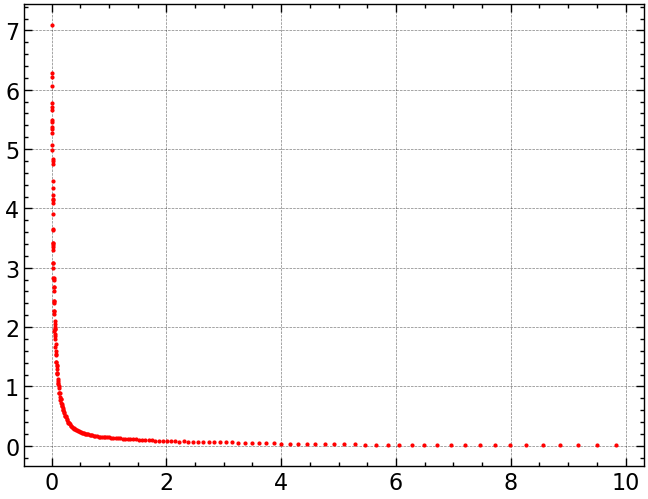

In [14]:
plt.plot(theta_bins, w_theta, 'r.', markersize=4, 
             label=f'Grid point: ZP_G={zp_G_example:.3f}, ZP_R={zp_R_example:.3f}')

/tmp/ipykernel_114522/653524858.py:33: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=ax, label='N objects')
/tmp/ipykernel_114522/653524858.py:42: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=ax, label='Valid')


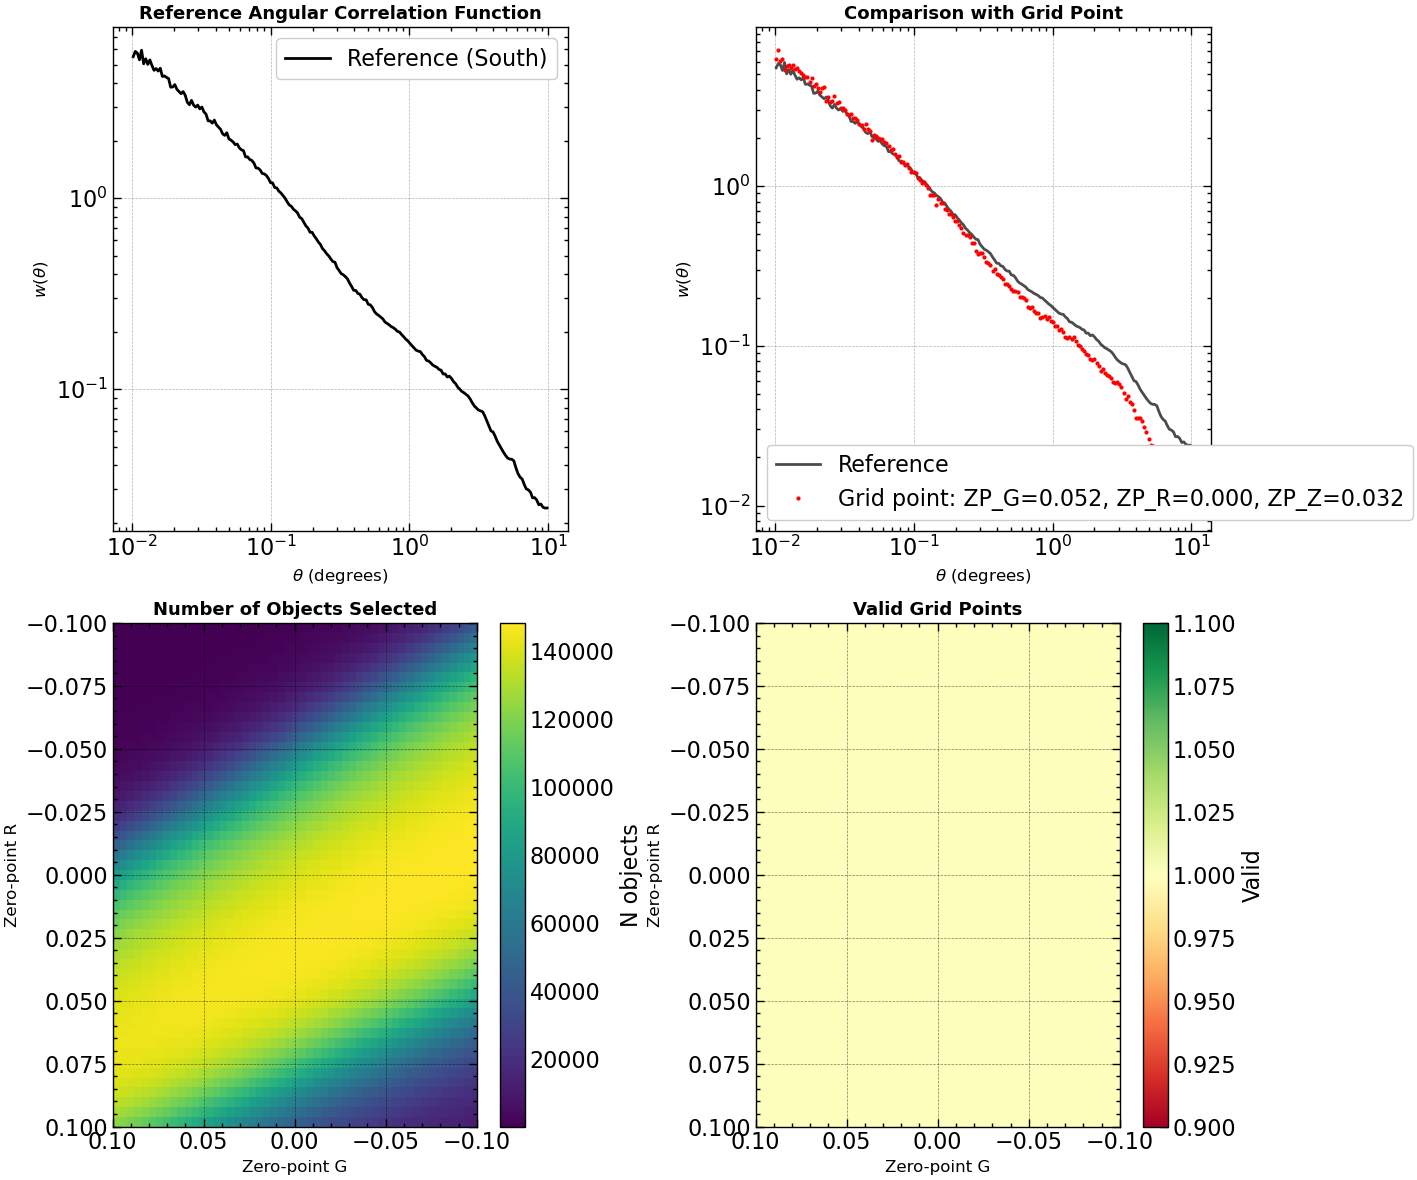

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Reference w_theta
ax = axes[0, 0]
ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=2, label='Reference (South)')
ax.set_xlabel(r'$\theta$ (degrees)', fontsize=12)
ax.set_ylabel(r'$w(\theta)$', fontsize=12)
ax.set_title('Reference Angular Correlation Function', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()
# Plot 2: Compare reference with example grid point
ax = axes[0, 1]
ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=2, label='Reference', alpha=0.7)
if valid_mask[i_example, j_example,k_example]:
    n_bins = n_bins_array[i_example, j_example,k_example]
    theta_bins = theta_bins_array[i_example, j_example, k_example, :n_bins]
    w_theta = w_theta_array[i_example, j_example, k_example, :n_bins]
    ax.loglog(theta_bins, w_theta, 'r.', markersize=4, 
             label=f'Grid point: ZP_G={zp_G_example:.3f}, ZP_R={zp_R_example:.3f}, ZP_Z={zp_Z_example:.3f}')
ax.set_xlabel(r'$\theta$ (degrees)', fontsize=12)
ax.set_ylabel(r'$w(\theta)$', fontsize=12)
ax.set_title('Comparison with Grid Point', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

# Plot 3: N objects heatmap
ax = axes[1, 0]
im = ax.imshow(n_objects_array[:, :, k_example].T, origin='lower', aspect='auto', cmap='viridis',
               extent=[grid_values[0], grid_values[-1], grid_values[0], grid_values[-1]])
ax.set_xlabel('Zero-point G', fontsize=12)
ax.set_ylabel('Zero-point R', fontsize=12)
ax.set_title('Number of Objects Selected', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='N objects')

# Plot 4: Valid points mask
ax = axes[1, 1]
im = ax.imshow(valid_mask[:, :, k_example].T, origin='lower', aspect='auto', cmap='RdYlGn',
               extent=[grid_values[0], grid_values[-1], grid_values[0], grid_values[-1]])
ax.set_xlabel('Zero-point G', fontsize=12)
ax.set_ylabel('Zero-point R', fontsize=12)
ax.set_title('Valid Grid Points', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Valid')
plt.tight_layout()

In [17]:
def calculate_chi_square(w_theta_grid, w_theta_ref, theta_bins_grid, theta_bins_ref):
    """
    Calculate chi-square between grid w_theta and reference w_theta
    by interpolating to match theta bins
    """
    # Interpolate grid w_theta to reference theta bins
    w_theta_interp = np.interp(theta_bins_ref, theta_bins_grid, w_theta_grid)
    
    # Calculate chi-square (assuming Poisson errors proportional to w_theta)
    # Using reference w_theta as the uncertainty estimate
    chi_square = np.sum((w_theta_interp - w_theta_ref)**2 / np.abs(w_theta_ref))
    
    return chi_square

# Calculate chi-square for all valid grid points
chi_square_grid = np.full((len(grid_values), len(grid_values), len(grid_values)), np.inf)

for i in range(len(grid_values)):
    for j in range(len(grid_values)):
        for k in range(len(grid_values)):
            if valid_mask[i, j, k]:
                n_bins = n_bins_array[i, j, k]
                theta_bins = theta_bins_array[i, j, k, :n_bins]
                w_theta = w_theta_array[i, j, k, :n_bins]
                
                chi_square_grid[i, j, k] = calculate_chi_square(
                    w_theta, reference_w_theta, theta_bins, reference_theta_bins
                )

print(f"Chi-square grid shape: {chi_square_grid.shape}")
print(f"Min chi-square: {np.min(chi_square_grid[valid_mask]):.2f}")
print(f"Max chi-square: {np.max(chi_square_grid[valid_mask]):.2f}")

# Find best-fit grid point
best_idx = np.unravel_index(np.argmin(chi_square_grid), chi_square_grid.shape)
print(f"\nBest-fit grid point: ({best_idx[0]}, {best_idx[1]}, {best_idx[2]})")
print(f"ZP_G = {grid_values[best_idx[0]]:.4f}, ZP_R = {grid_values[best_idx[1]]:.4f}, ZP_Z = {grid_values[best_idx[2]]:.4f}")
print(f"Chi-square = {chi_square_grid[best_idx]:.2f}")

Chi-square grid shape: (51, 51, 51)
Min chi-square: 0.63
Max chi-square: 28649504.31

Best-fit grid point: (0, 24, 50)
ZP_G = 0.1000, ZP_R = 0.0040, ZP_Z = -0.1000
Chi-square = 0.63


In [28]:
np.mean(chi_square_grid.ravel())

81630.30783478115

In [36]:
np.min(chi_square_grid.ravel())

0.6305679859319346

(-1.0, 100.0)

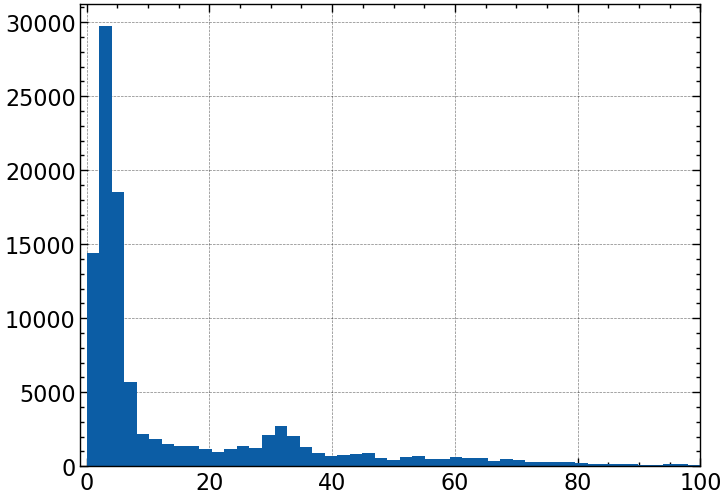

In [38]:
bins = np.linspace(0,100,50)
plt.hist(chi_square_grid.ravel(),bins=bins)
plt.xlim(-1,100)

/tmp/ipykernel_114522/1664786644.py:33: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(cs, label='Δχ²')


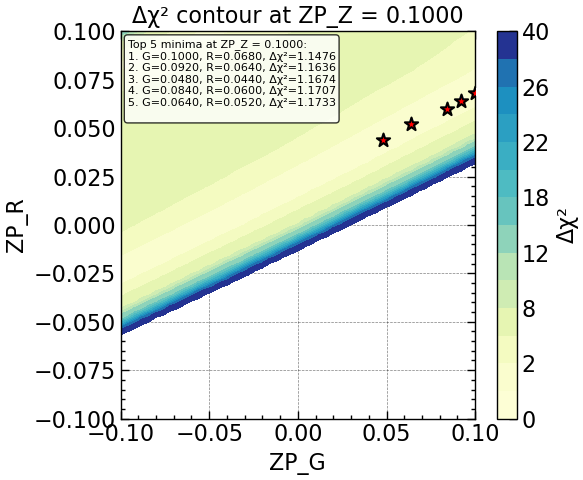

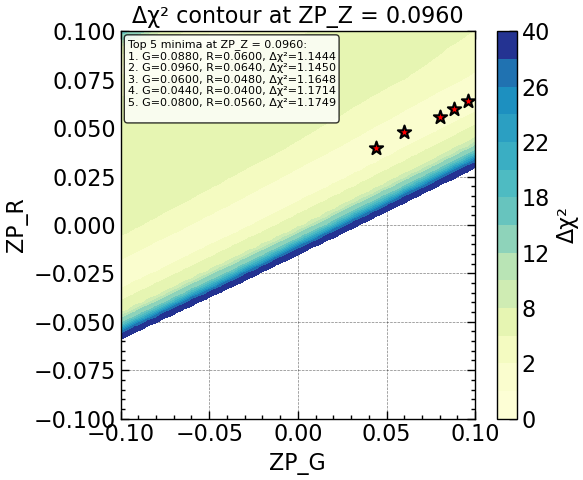

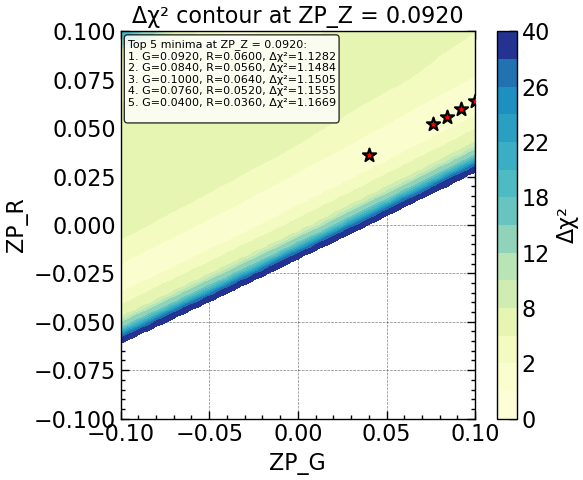

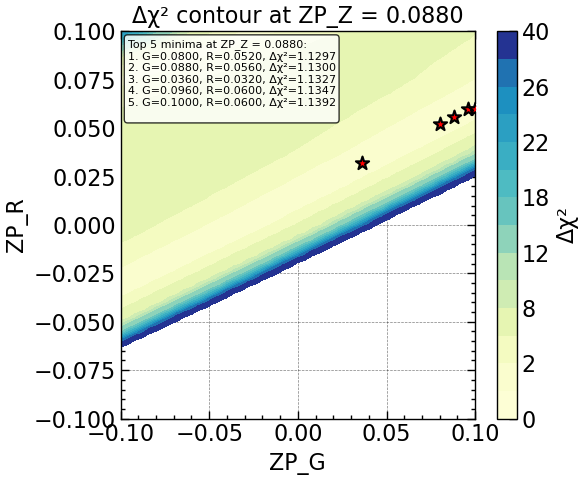

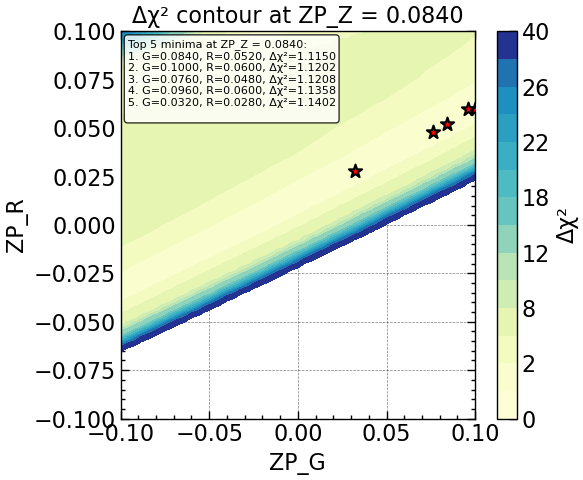

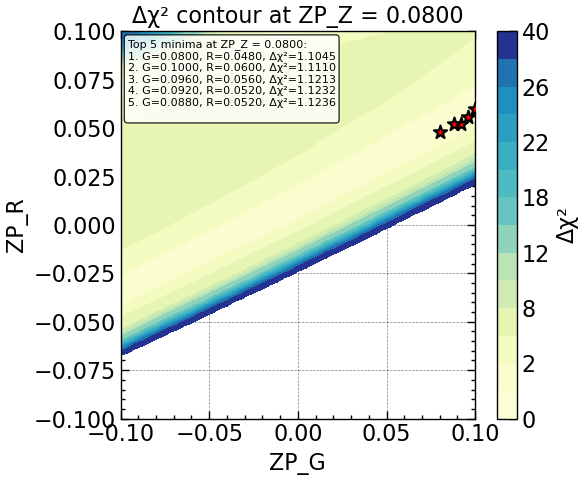

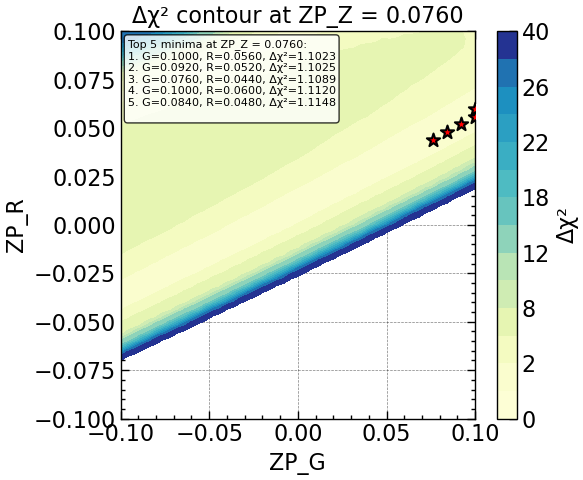

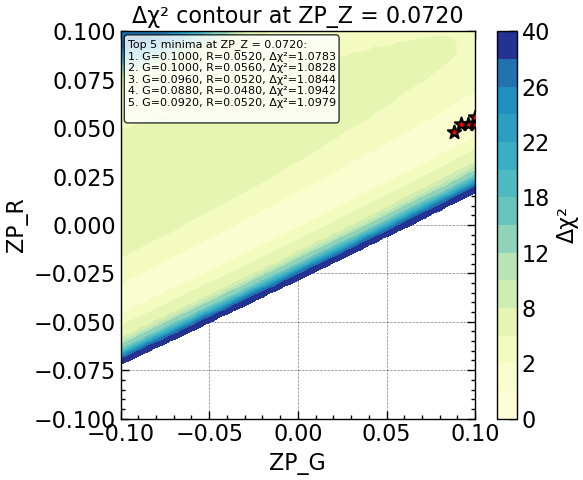

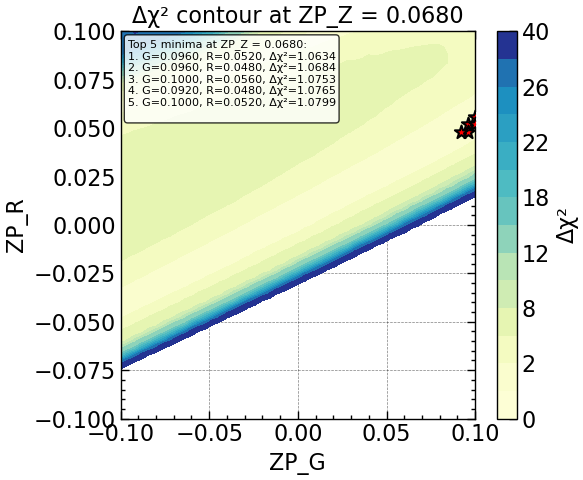

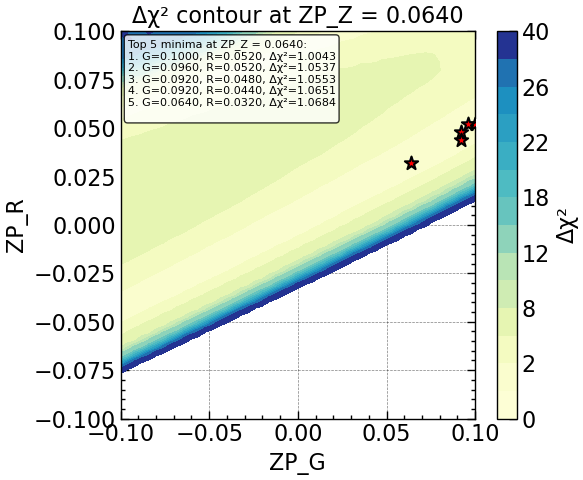

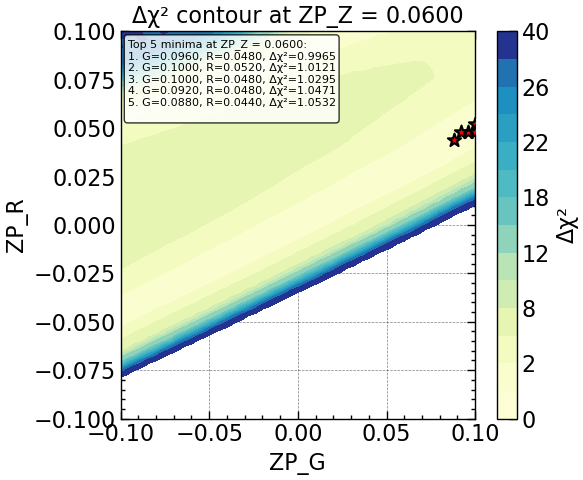

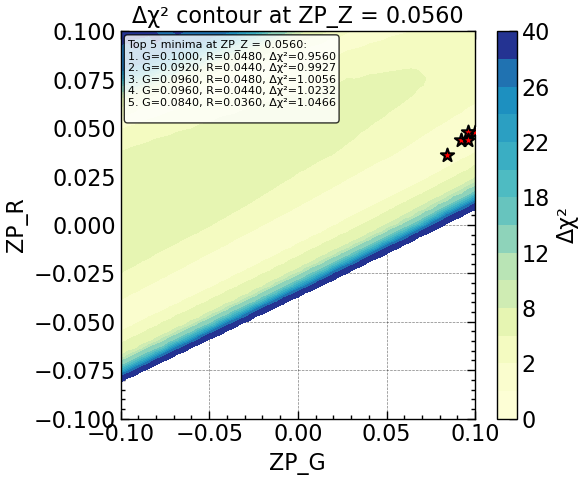

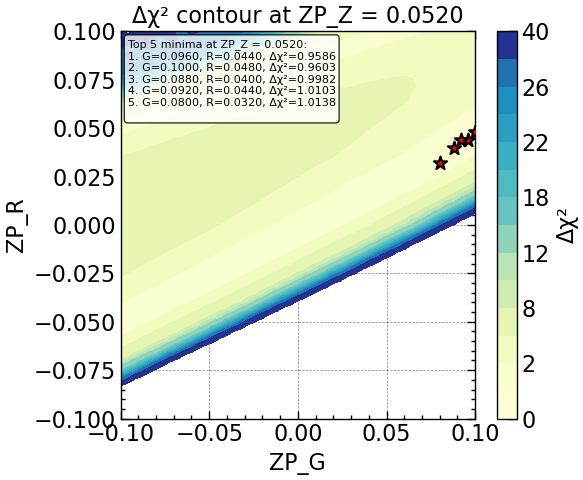

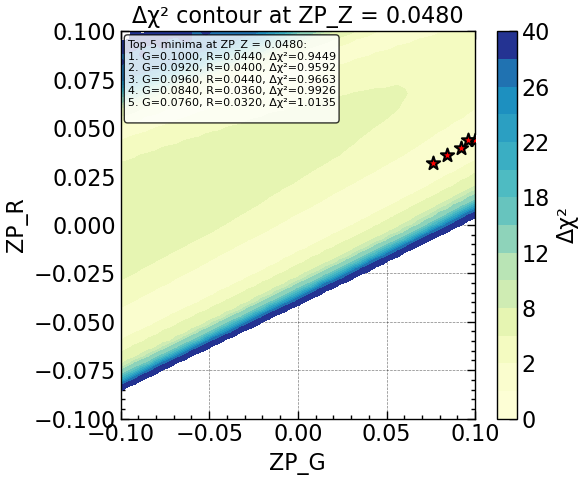

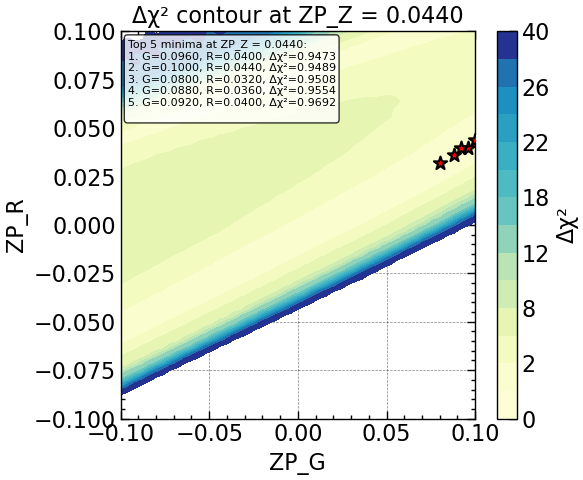

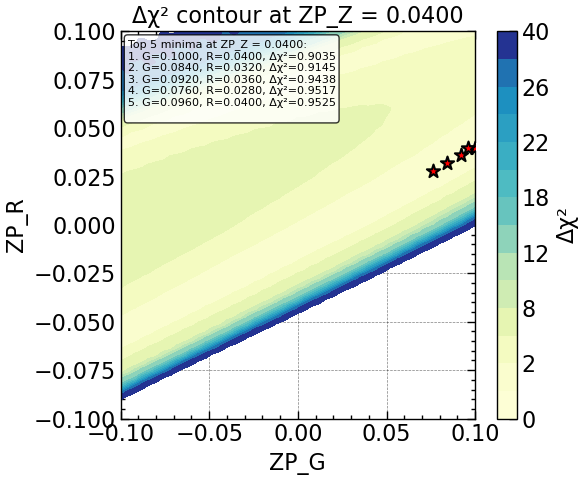

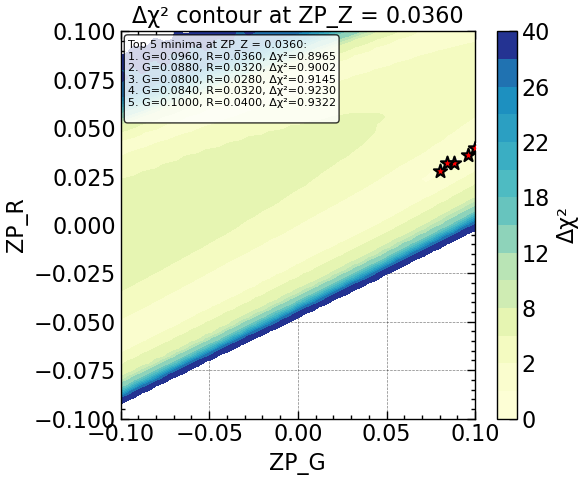

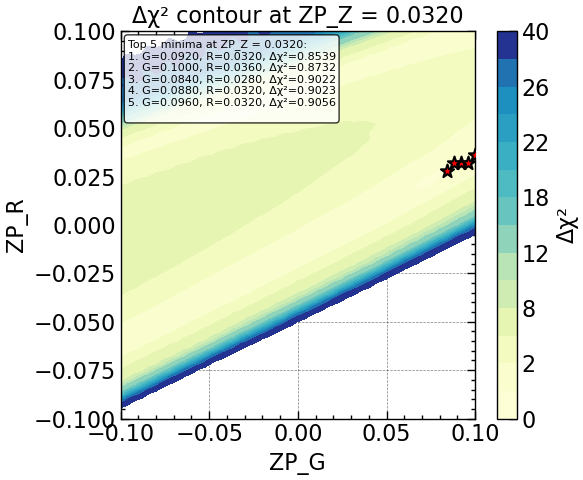

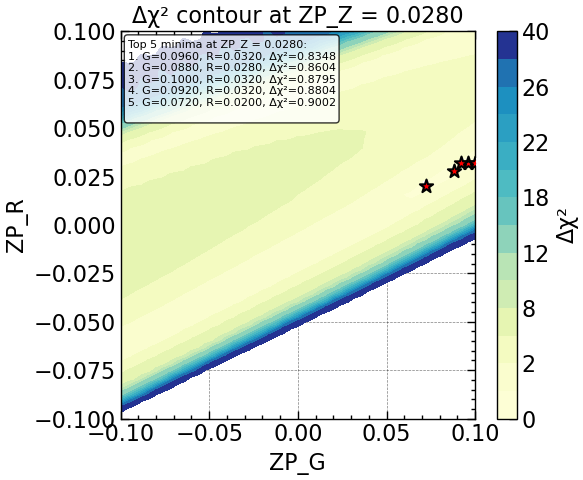

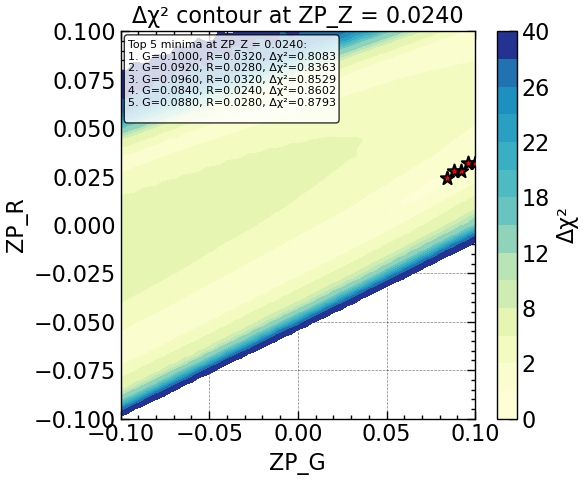

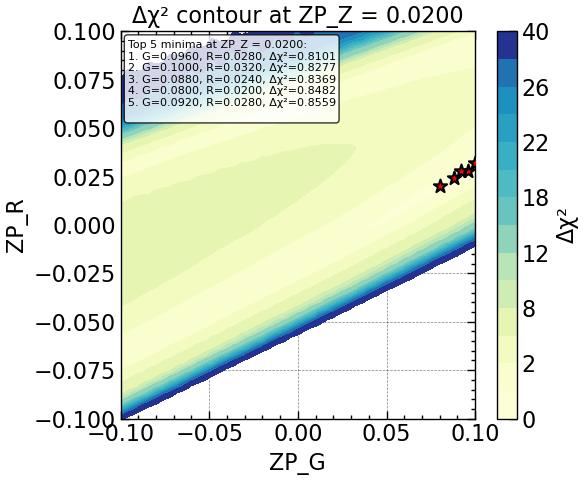

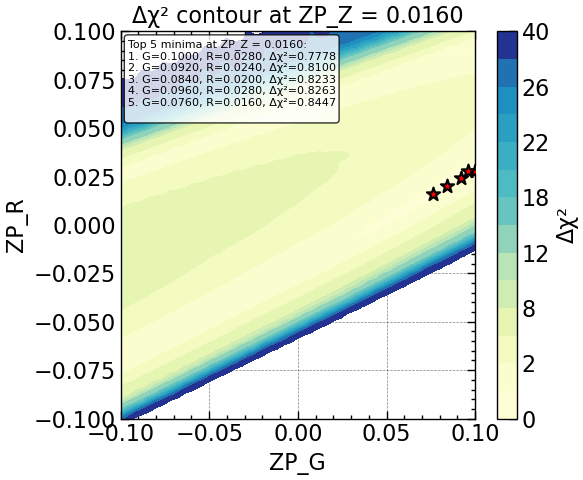

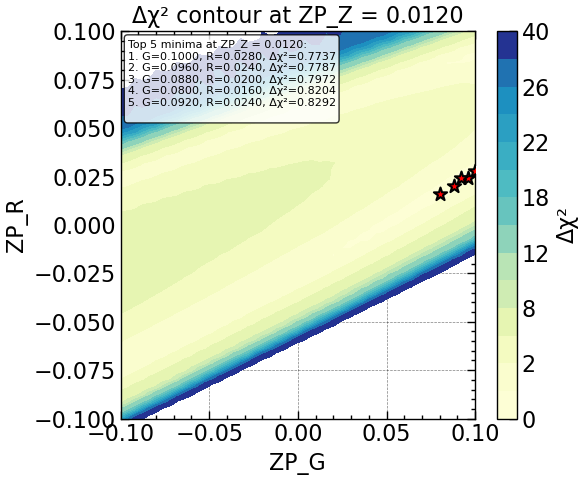

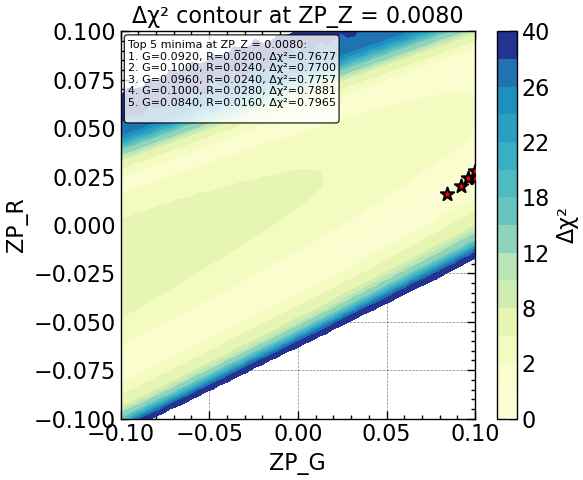

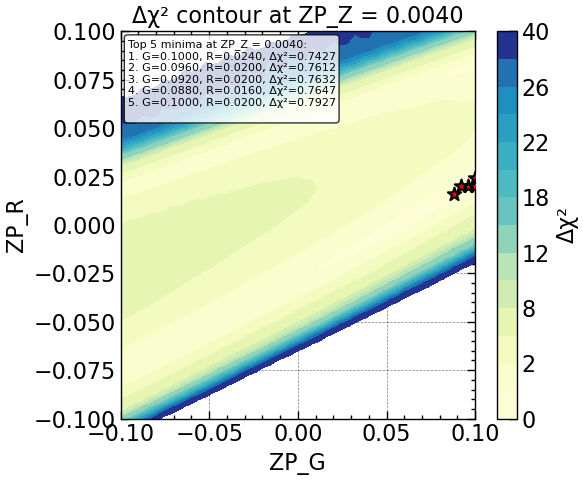

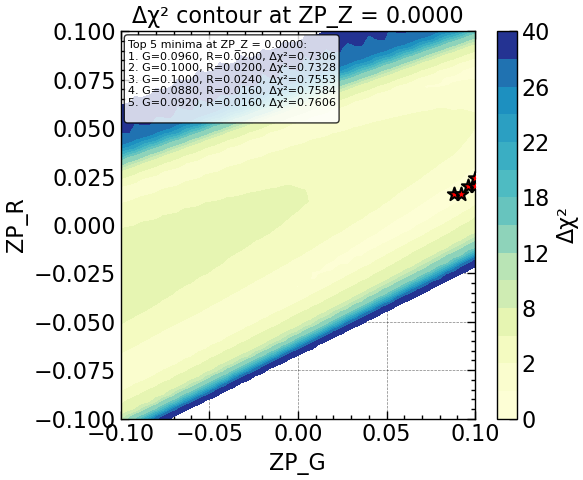

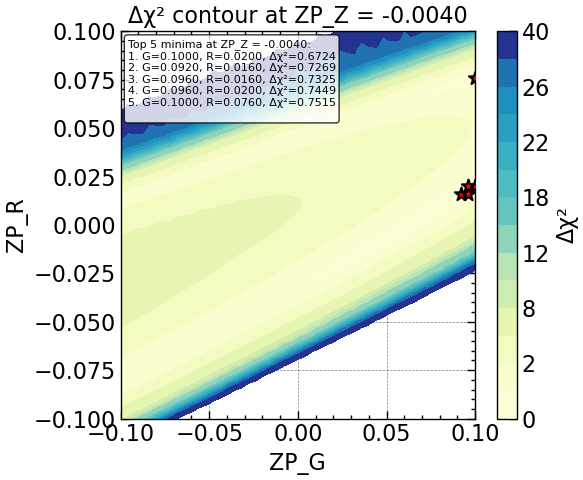

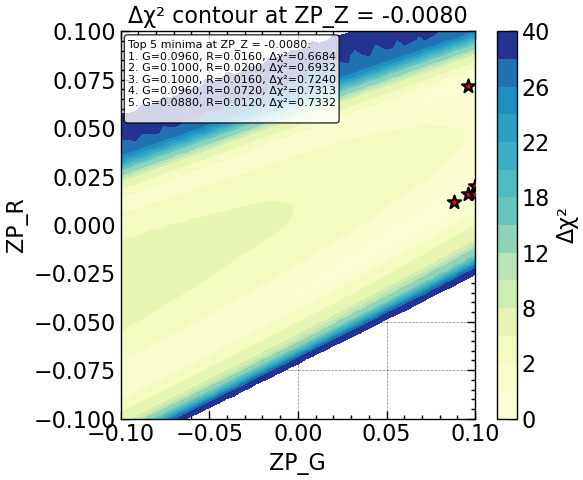

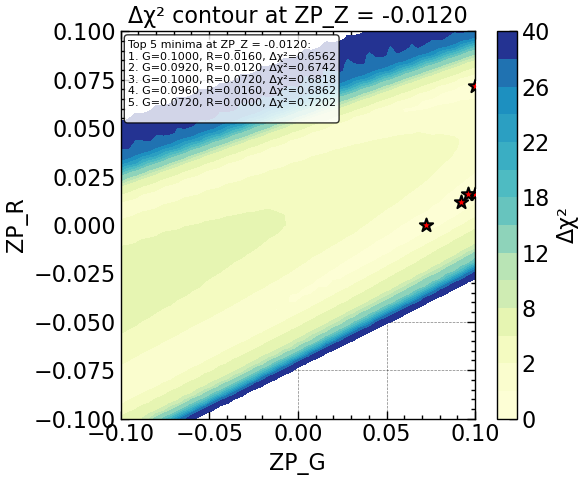

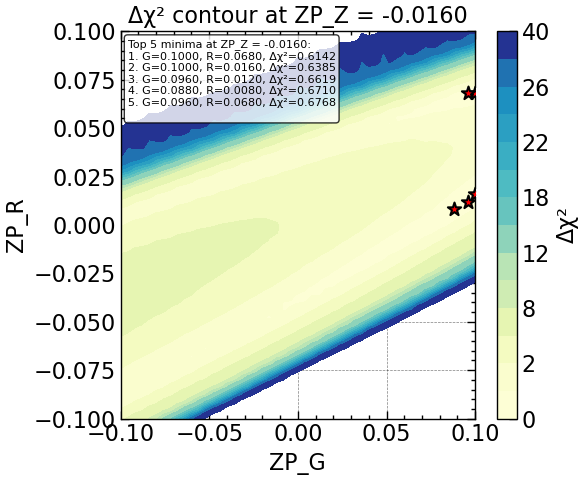

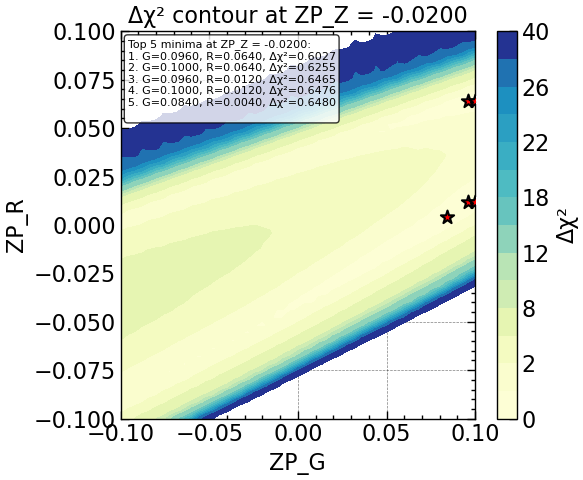

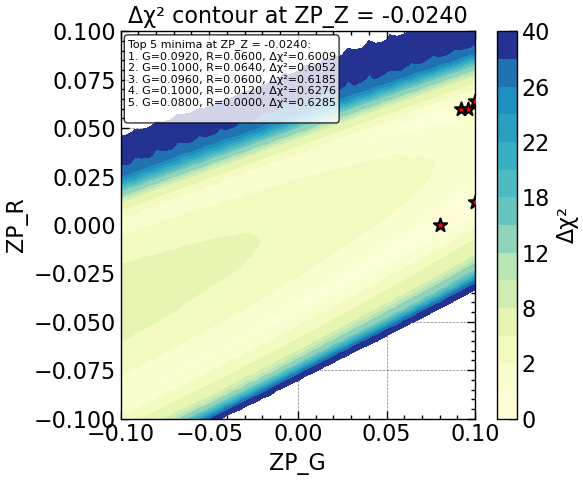

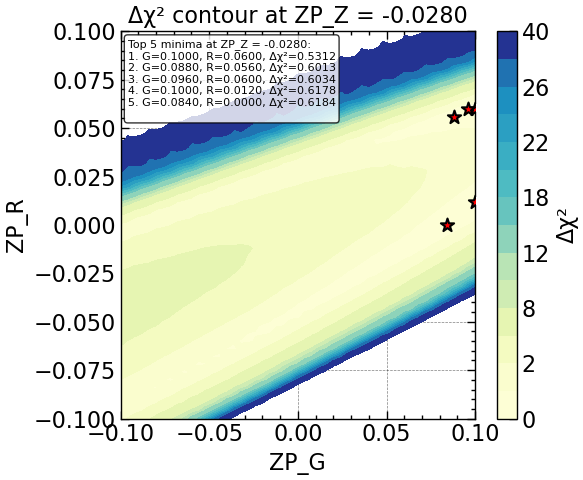

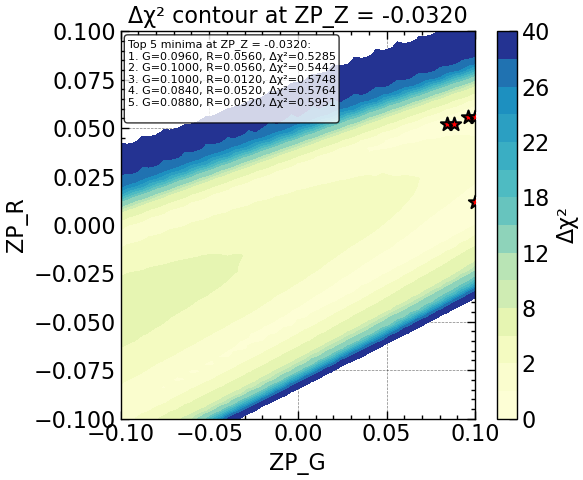

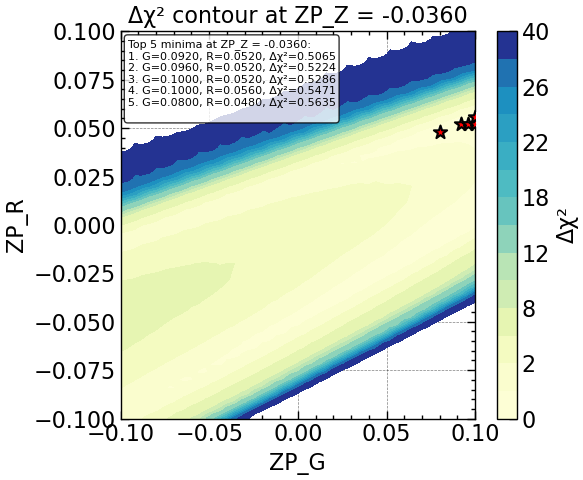

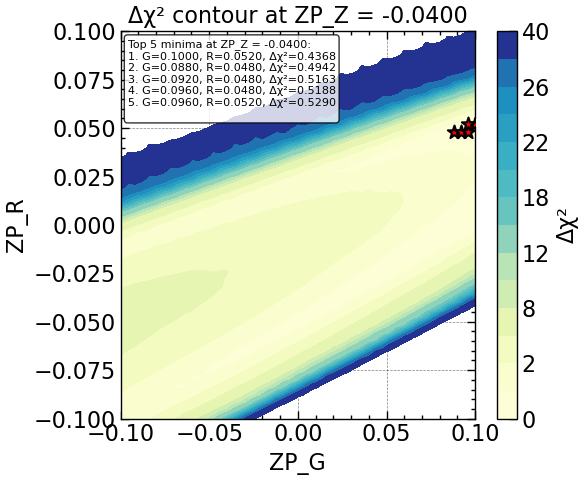

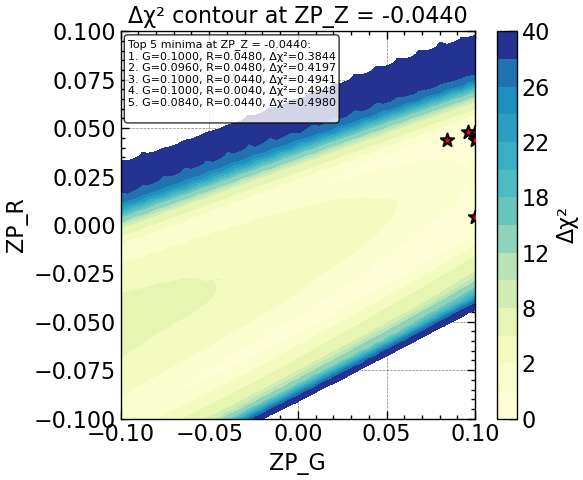

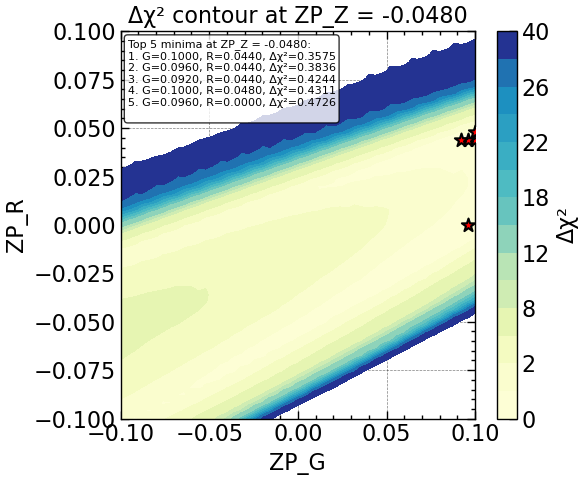

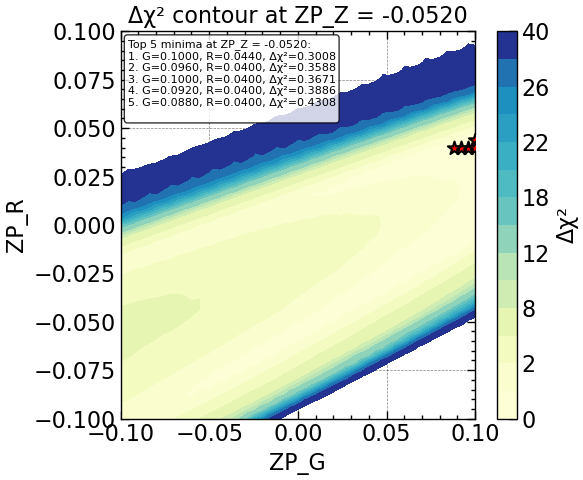

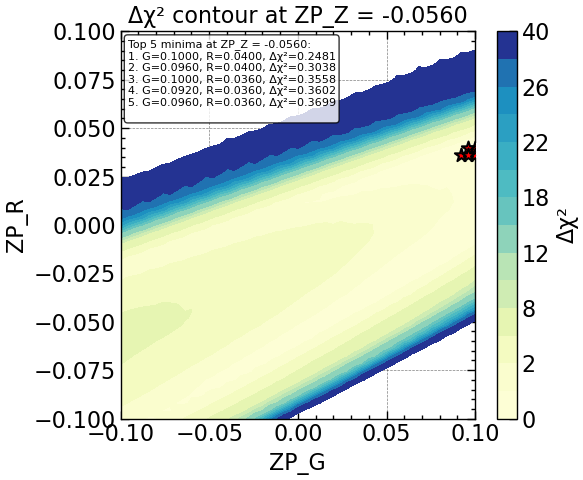

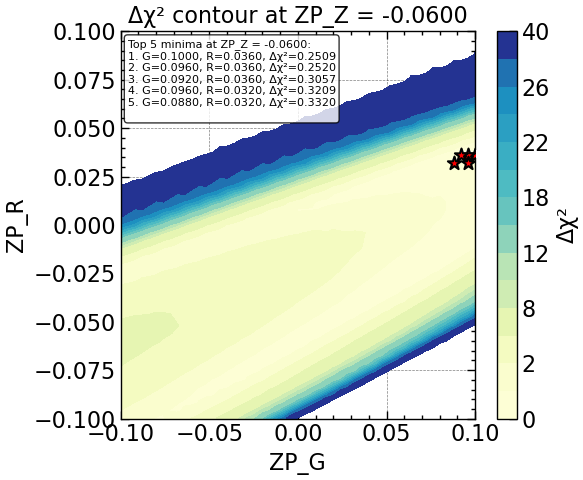

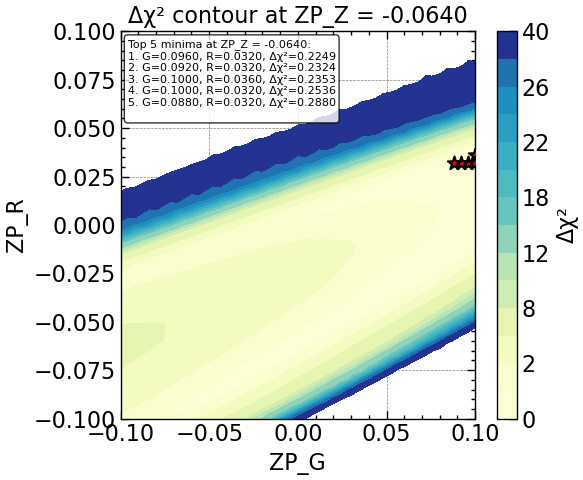

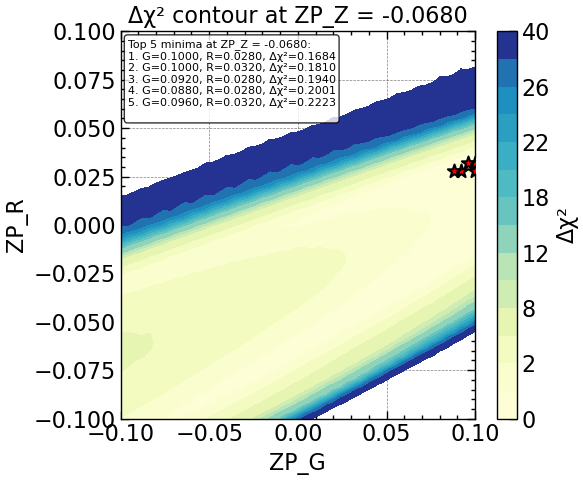

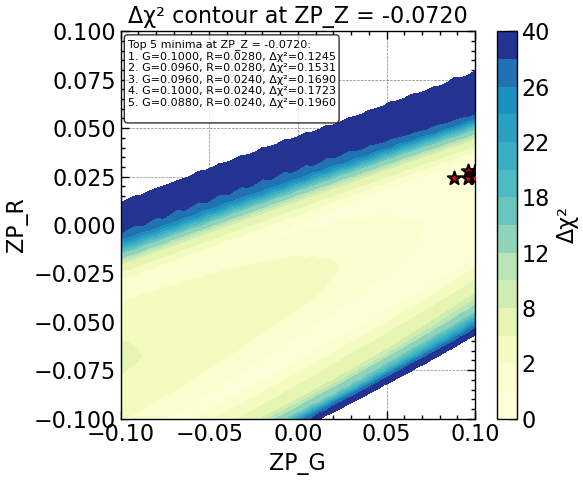

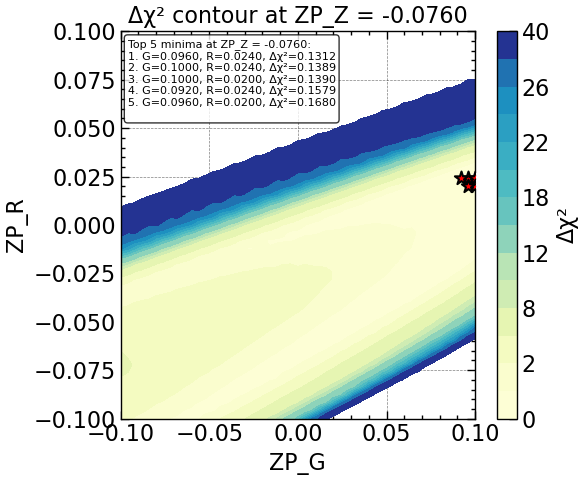

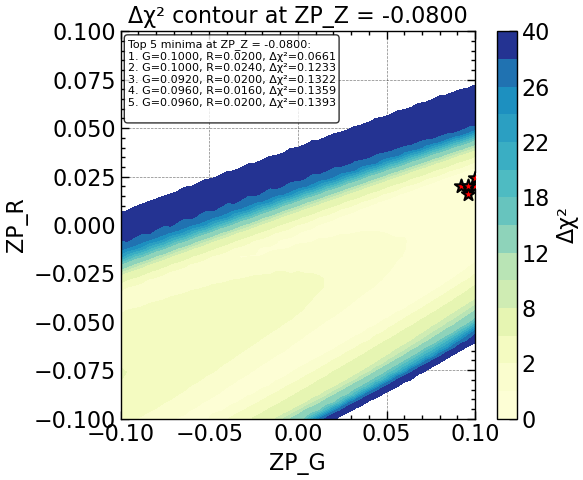

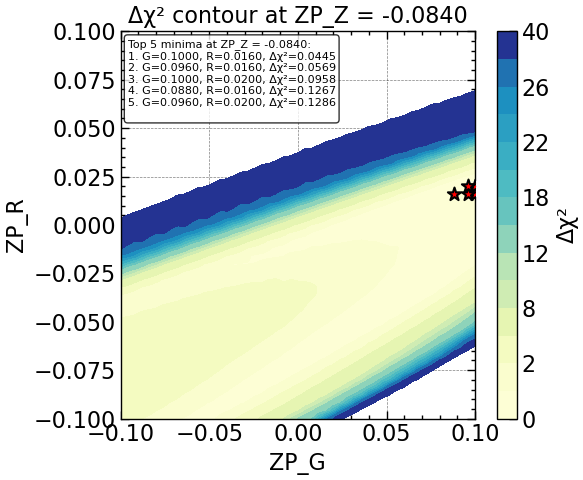

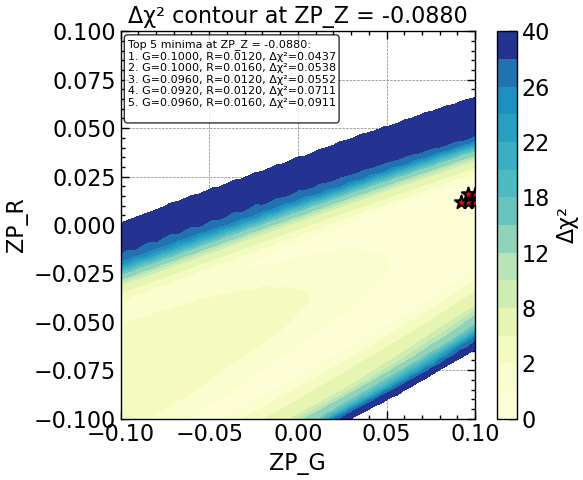

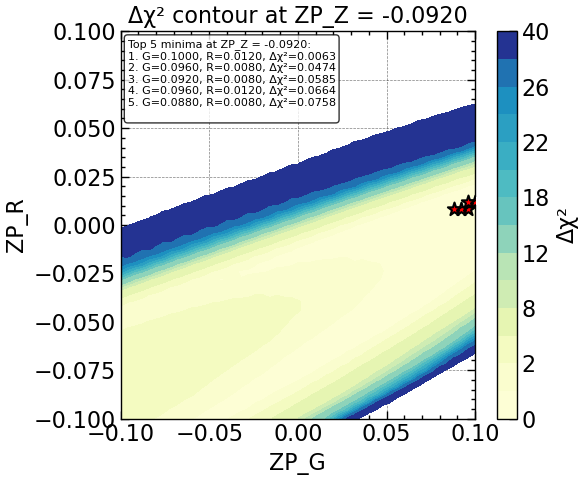

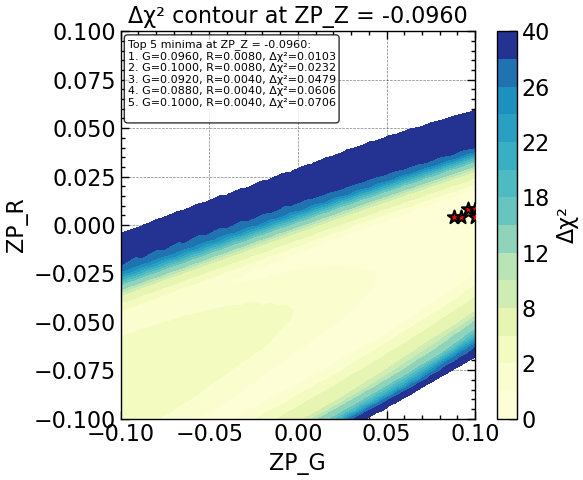

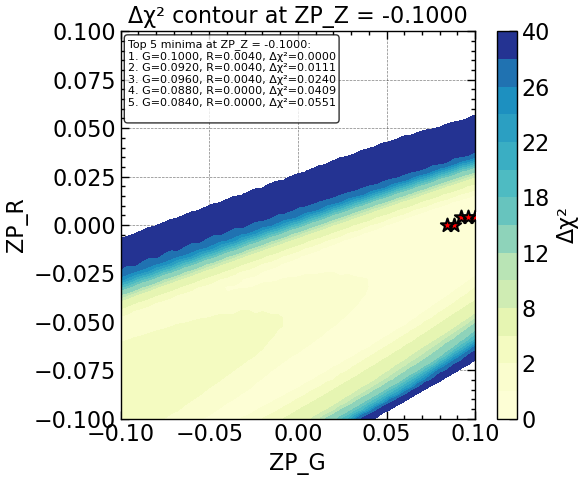

In [104]:
import matplotlib.pyplot as plt
import numpy as np

chi = chi_square_grid - np.nanmin(chi_square_grid)
grid = grid_values

for k in range(len(grid)):
    slice_2d = chi[:, :, k]
    slice_2d_clean = np.where(np.isinf(slice_2d), np.nan, slice_2d)
    
    # Find 5 minimum chi-square values in this slice
    valid_indices = np.where(~np.isnan(slice_2d_clean) & ~np.isinf(slice_2d_clean))
    if len(valid_indices[0]) > 0:
        valid_chi = slice_2d_clean[valid_indices]
        n_min = min(5, len(valid_chi))
        min_indices = np.argpartition(valid_chi, n_min-1)[:n_min]
        
        min_i = valid_indices[0][min_indices]
        min_j = valid_indices[1][min_indices]
        min_chi_values = valid_chi[min_indices]
        
        # Sort by chi-square value
        sort_order = np.argsort(min_chi_values)
        min_i = min_i[sort_order]
        min_j = min_j[sort_order]
        min_chi_values = min_chi_values[sort_order]
    
    # Create a new figure for each ZP_Z slice
    plt.figure(figsize=(6, 5))
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    
    cs = plt.contourf(X, Y, slice_2d_clean, levels=[0,1,2,4,8,10,12,16,18,20,22,24,26,30,40], cmap='YlGnBu')
    plt.colorbar(cs, label='Δχ²')
    
    # Plot minimum points
    if len(valid_indices[0]) > 0:
        for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
            plt.scatter(grid[i], grid[j], c='red', s=100, marker='*', 
                       edgecolors='black', linewidths=1.5, zorder=10)
            plt.text(grid[i], grid[j], f'{idx+1}', fontsize=8, ha='center', 
                    va='center', color='white', fontweight='bold')
        
        # Add text box with minimum points info
        text_str = f"Top {n_min} minima at ZP_Z = {grid[k]:.4f}:\n"
        for idx, (i, j, chi_val) in enumerate(zip(min_i, min_j, min_chi_values)):
            text_str += f"{idx+1}. G={grid[i]:.4f}, R={grid[j]:.4f}, Δχ²={chi_val:.4f}\n"
        
        plt.text(0.02, 0.98, text_str, transform=plt.gca().transAxes,
                fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='white', alpha=0.8))
    
    plt.title(f"Δχ² contour at ZP_Z = {grid[k]:.4f}")
    plt.xlabel("ZP_G")
    plt.ylabel("ZP_R")
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

chi = chi_square_grid - np.nanmin(chi_square_grid)
grid = grid_values

for k in range(len(grid)):
    slice_2d = chi[:, :, k]
    slice_2d = np.where(np.isinf(slice_2d), np.nan, slice_2d)
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    plt.figure(figsize=(6,5))
    cs = plt.contourf(X, Y, slice_2d, levels=[0,1,2,4,8,10,12,16,18,20,22,24,26,30,40], cmap='YlGnBu')
    plt.colorbar(cs, label='Δχ²')
    plt.title(f"Δχ² contour at ZP_Z = {grid[k]:.4f}")
    plt.xlabel("ZP_G")
    plt.ylabel("ZP_R")

200

/tmp/ipykernel_114522/431454023.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(cs, label='Δχ²')
/tmp/ipykernel_114522/431454023.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(6,5))


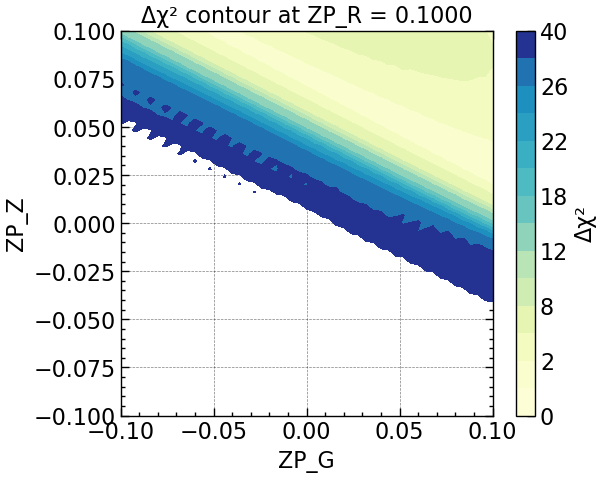

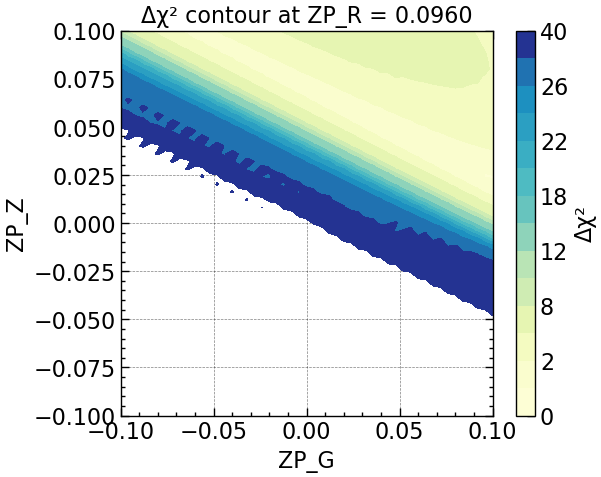

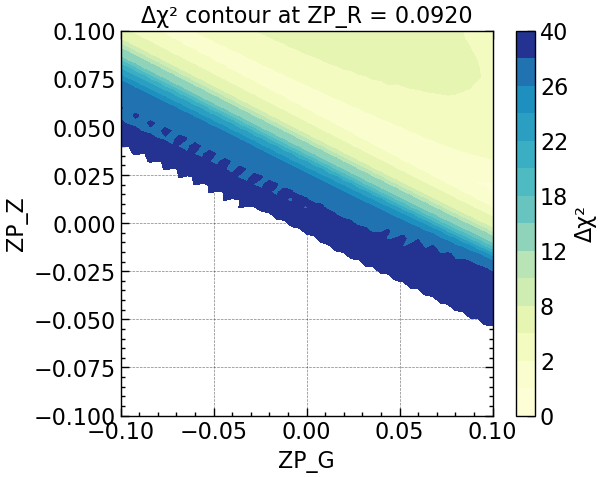

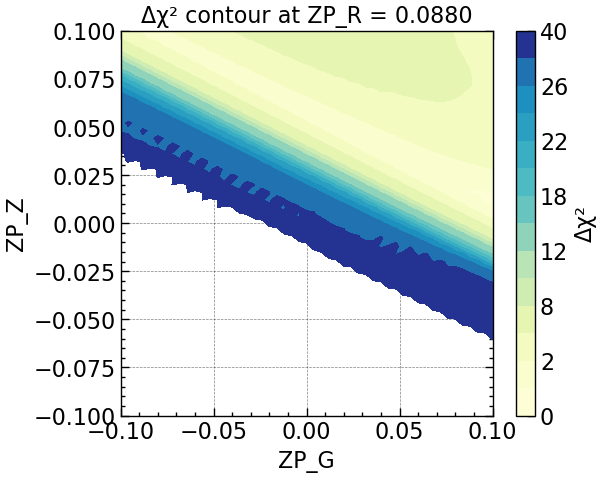

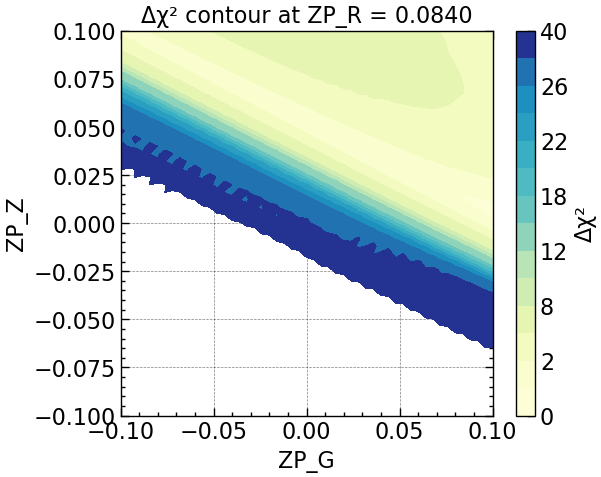

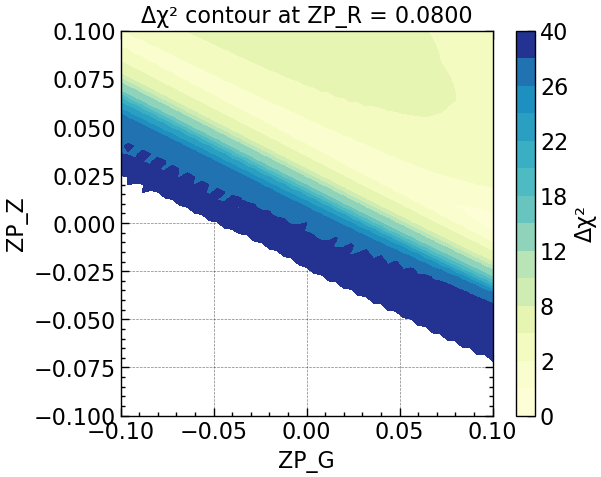

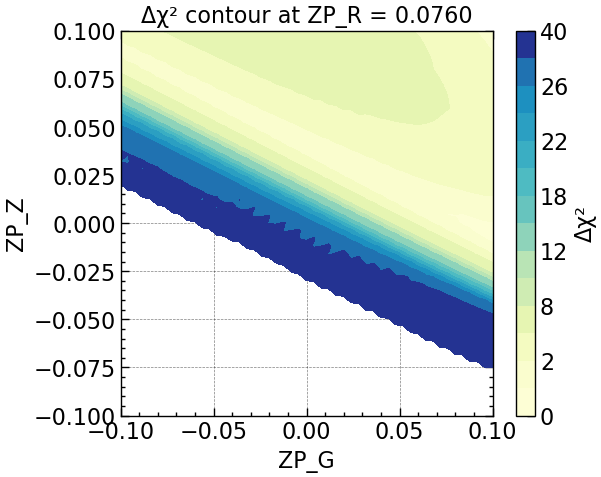

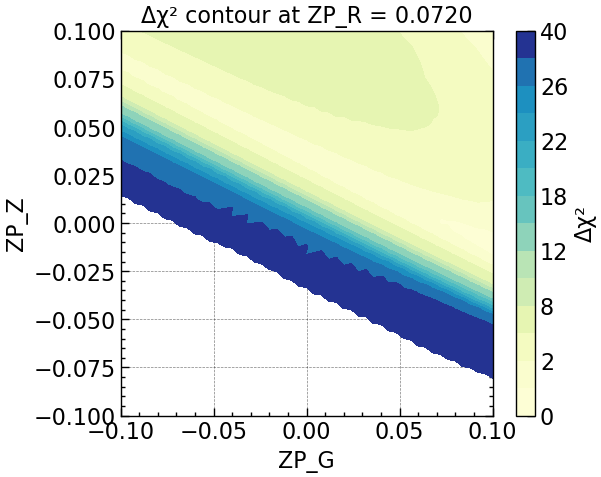

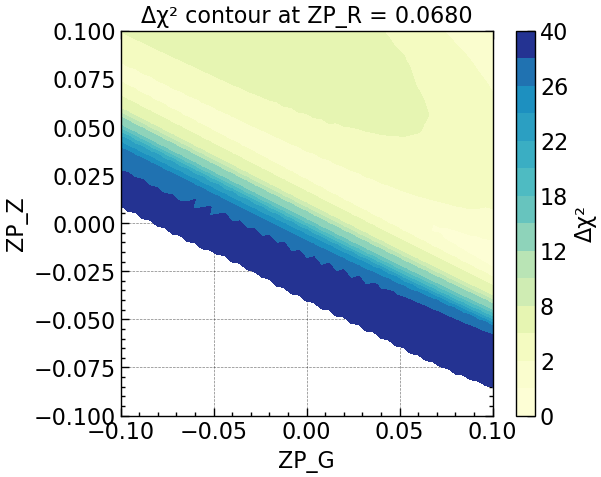

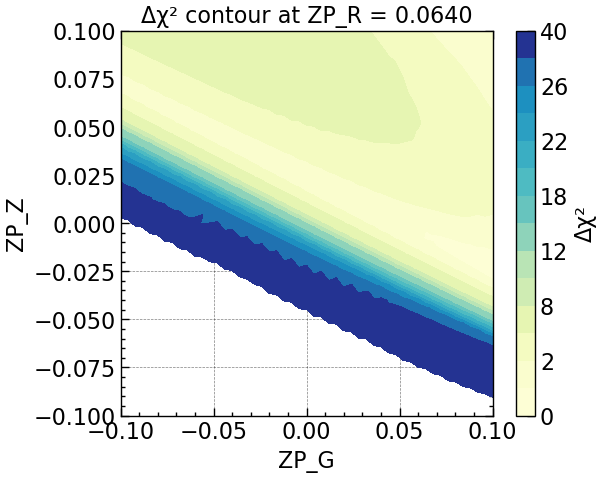

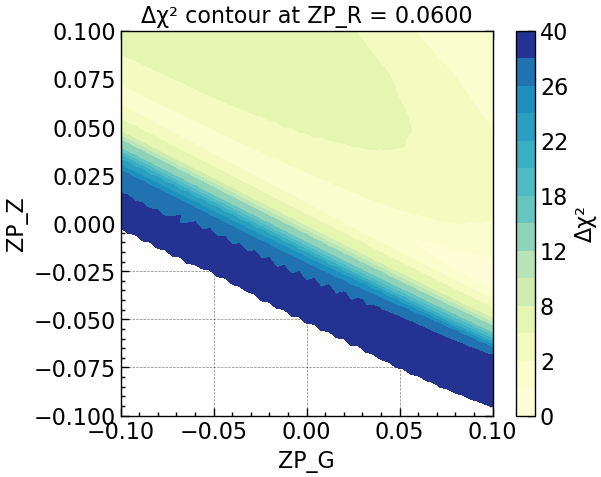

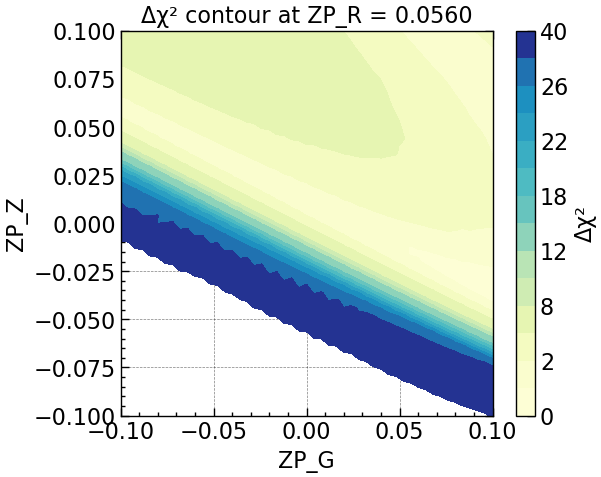

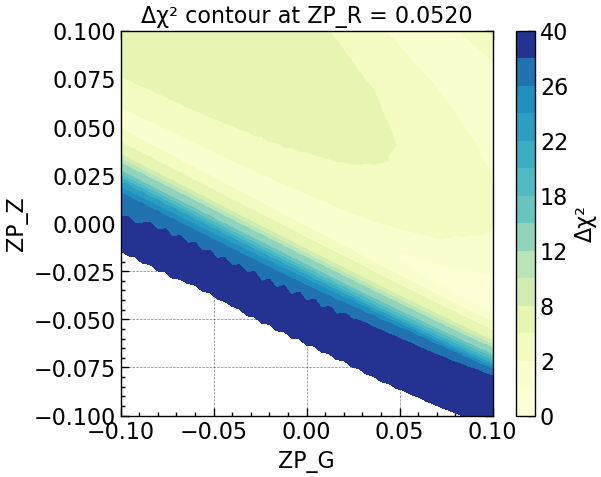

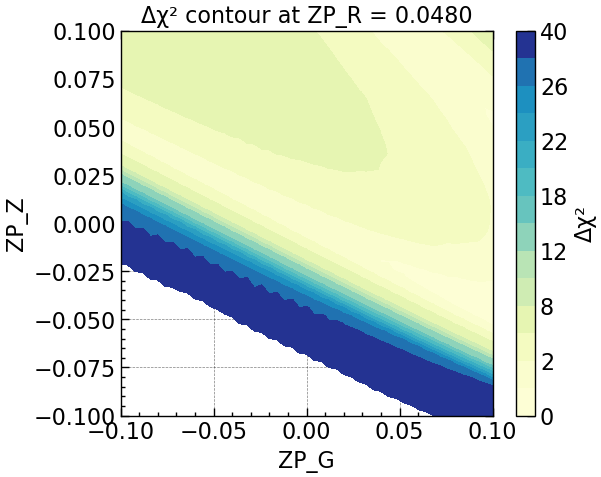

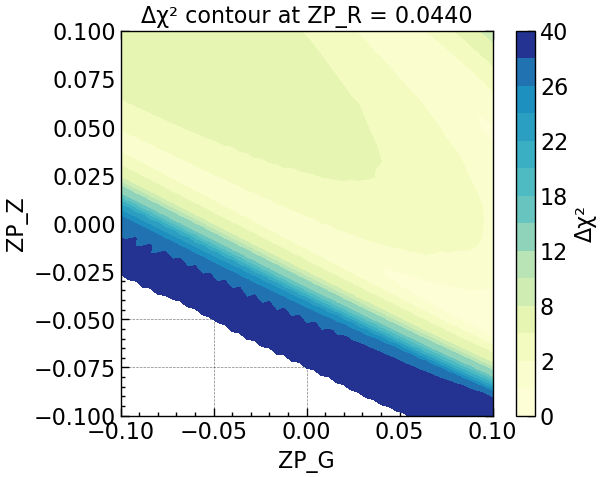

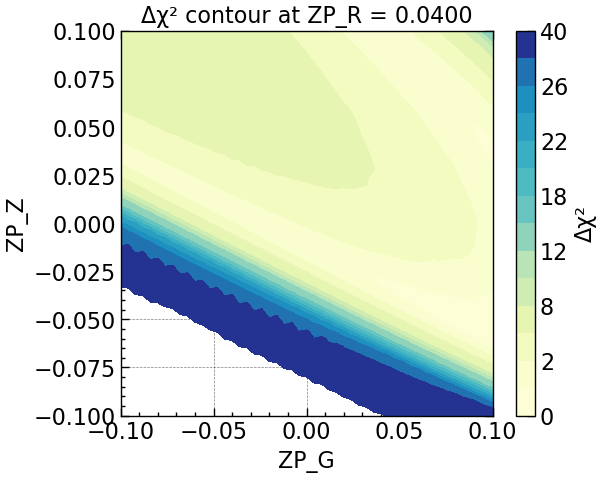

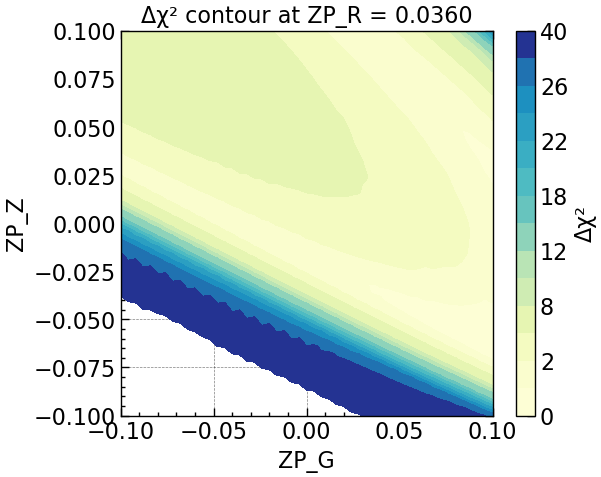

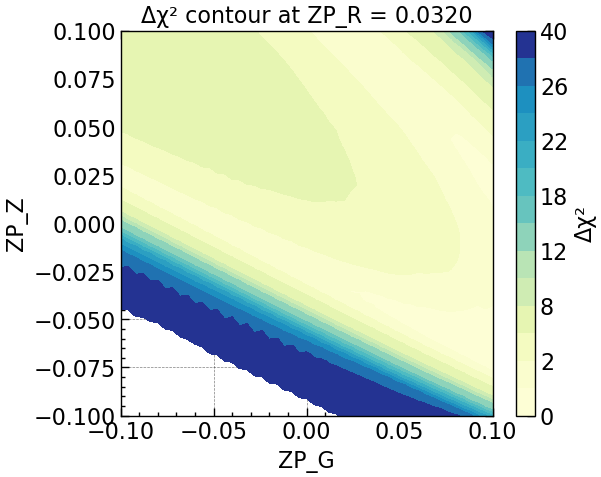

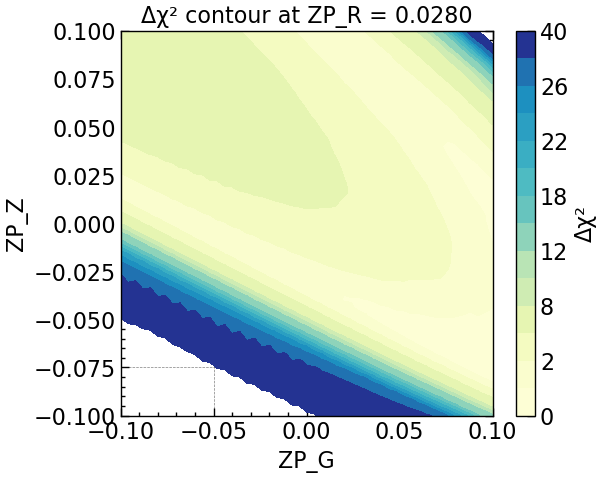

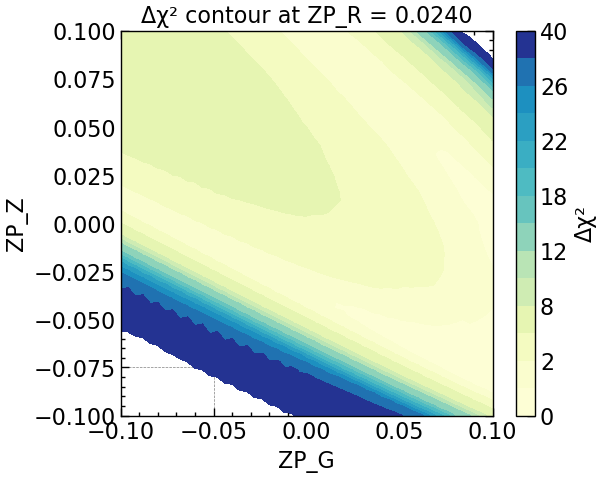

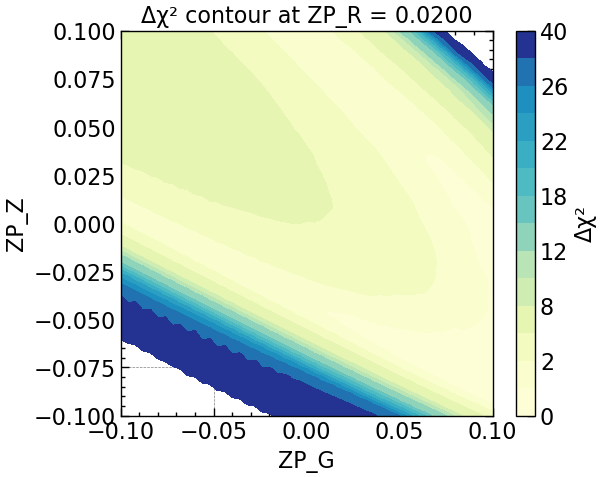

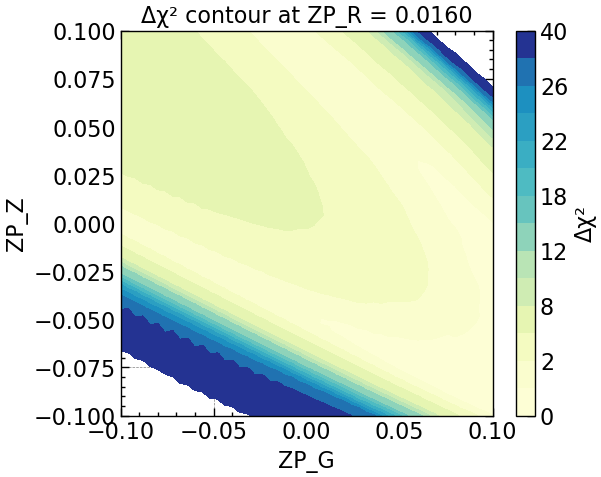

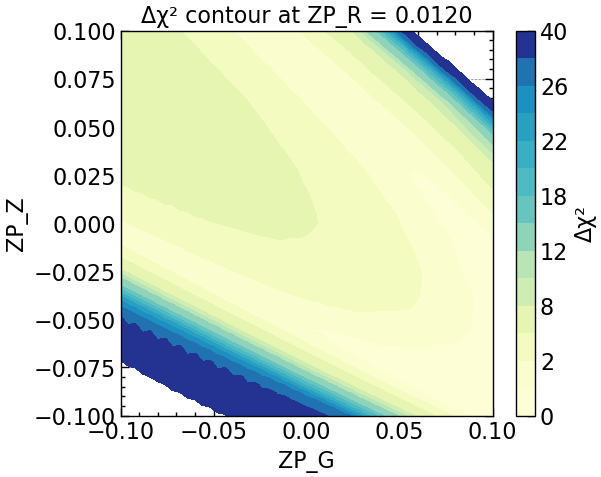

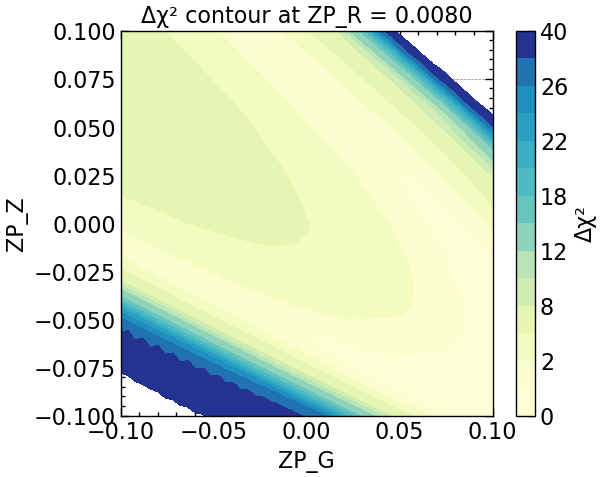

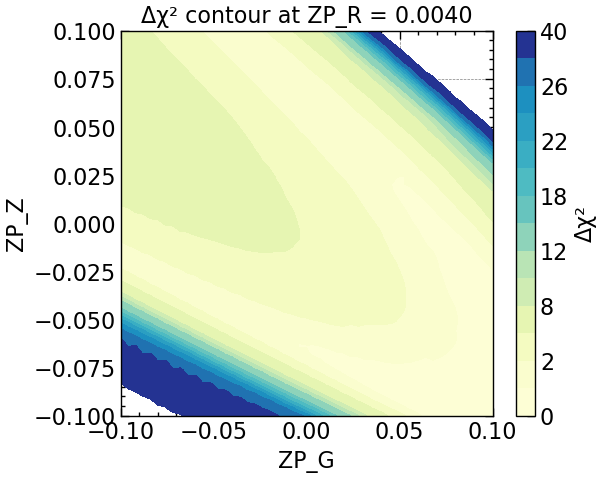

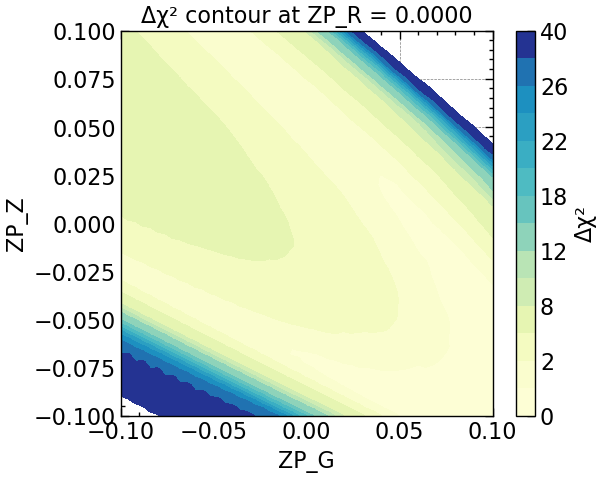

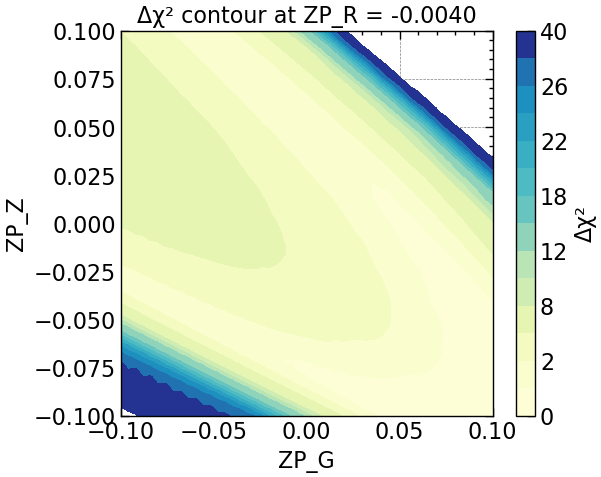

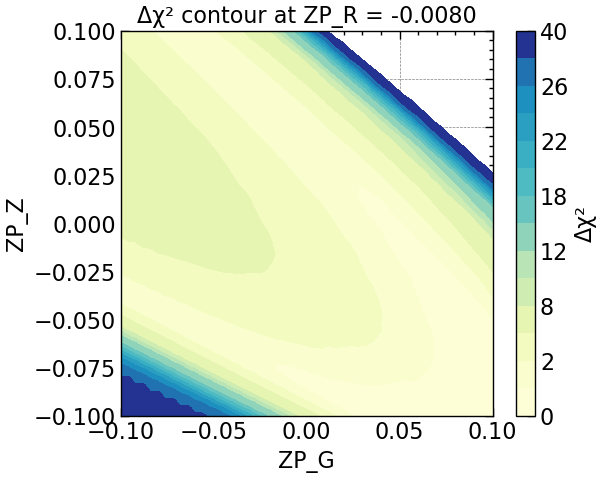

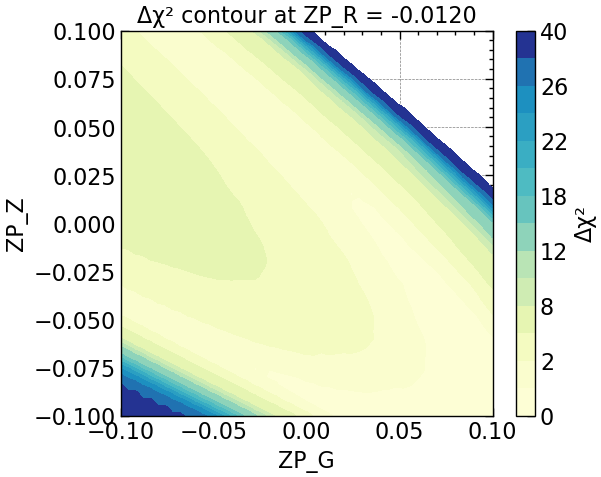

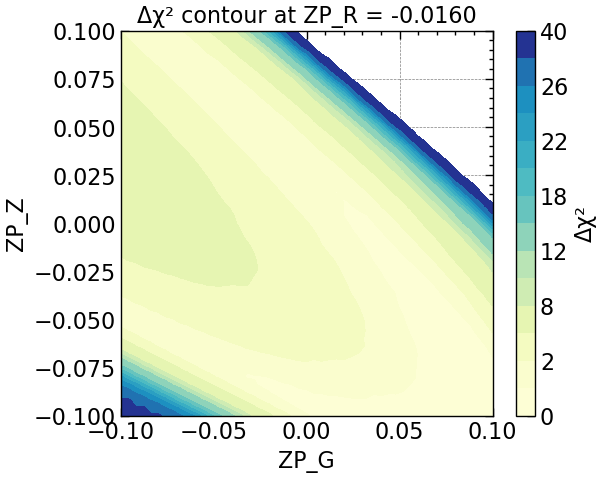

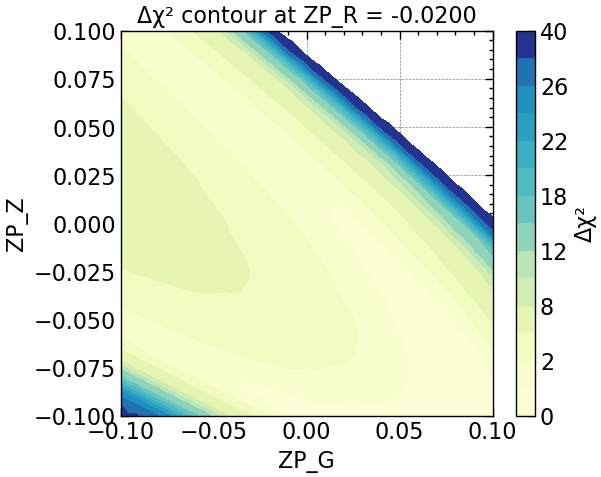

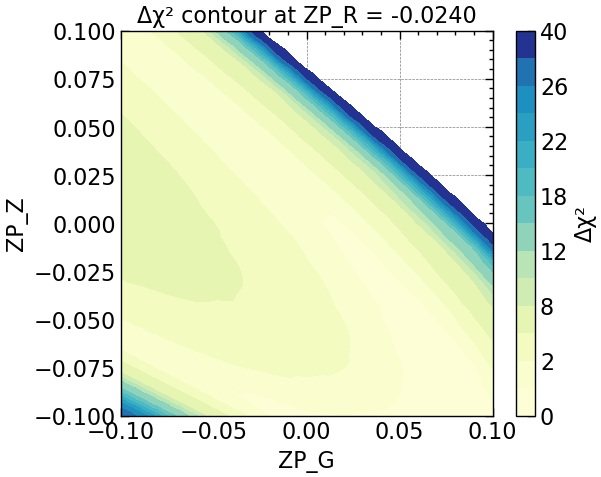

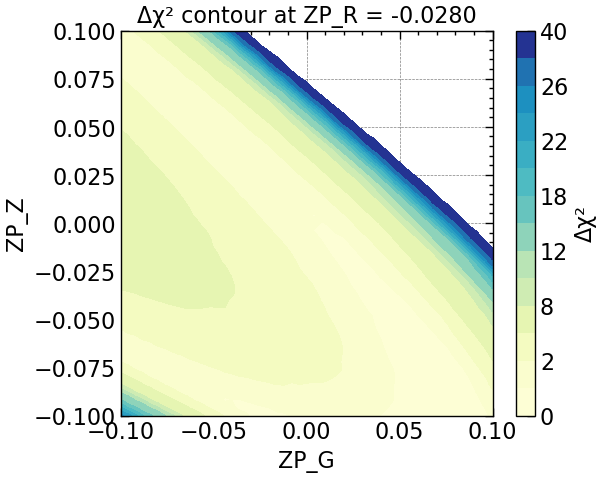

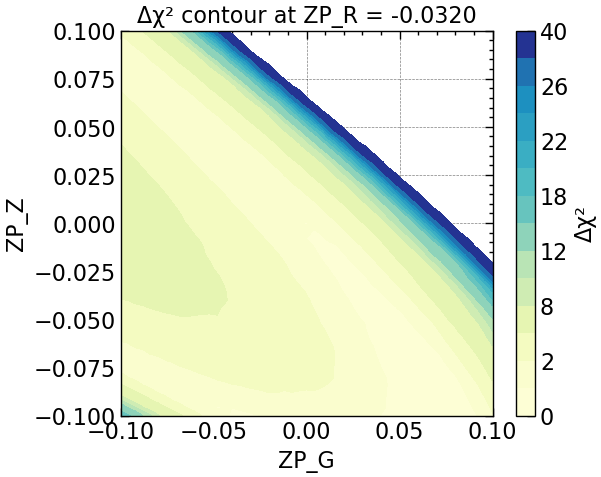

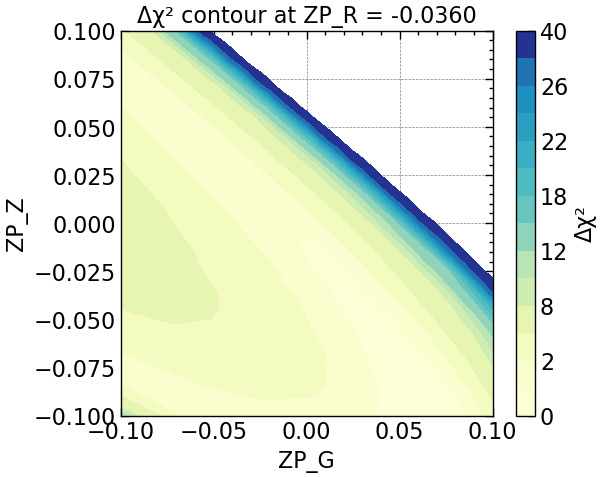

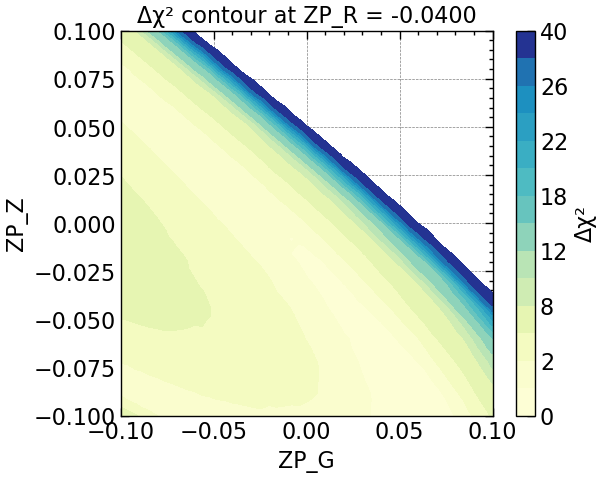

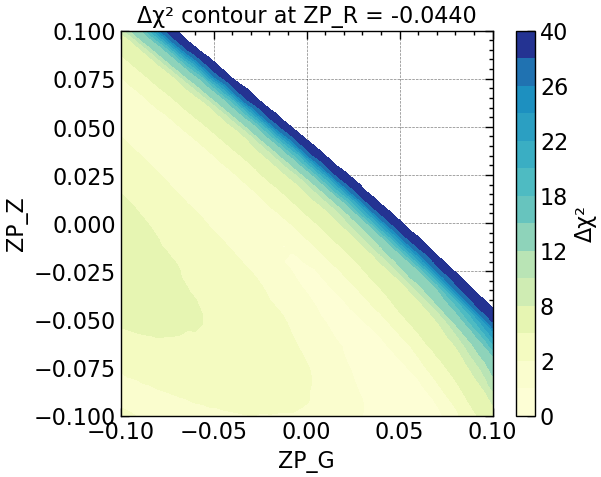

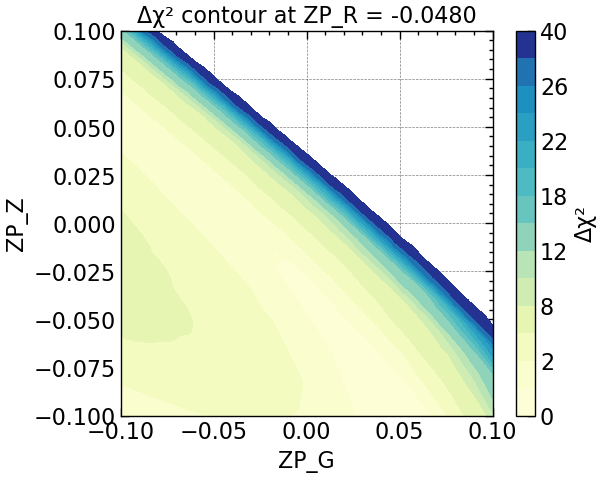

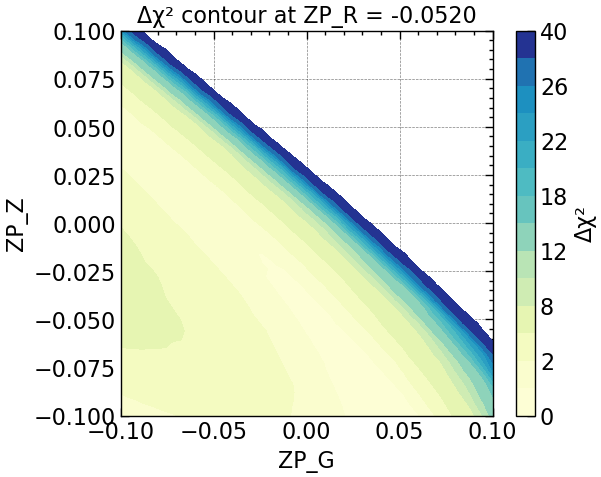

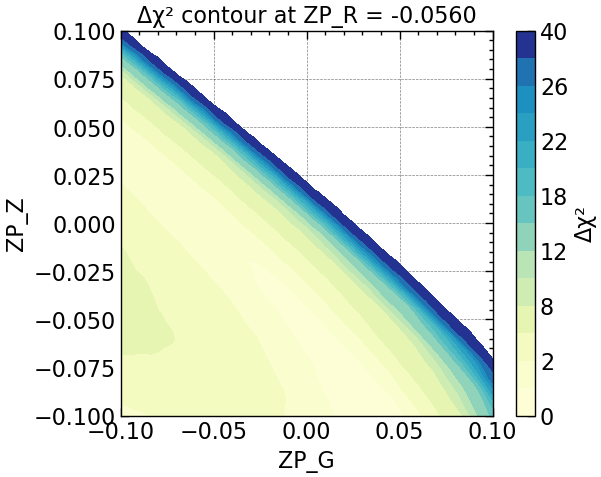

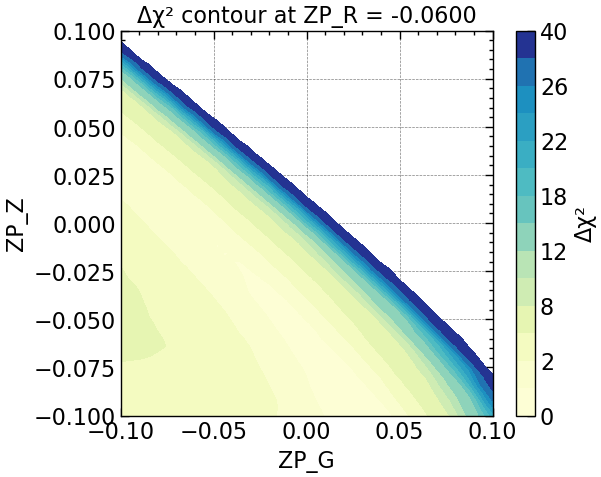

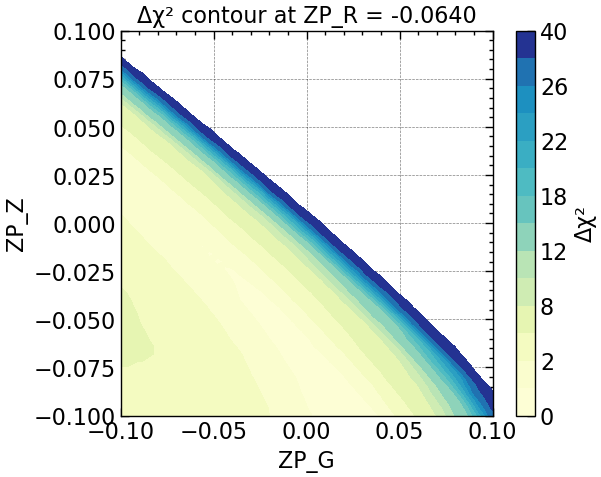

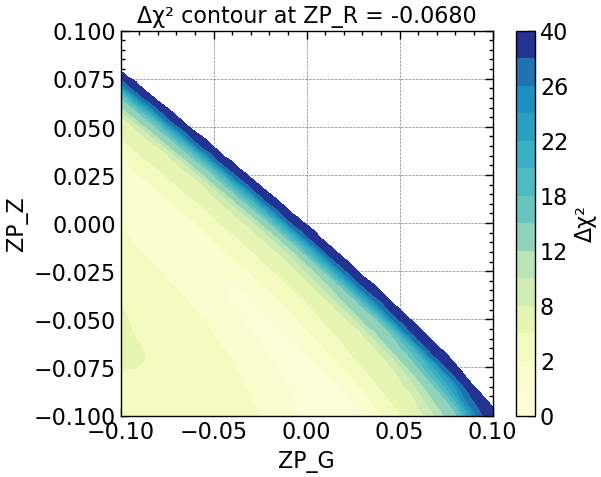

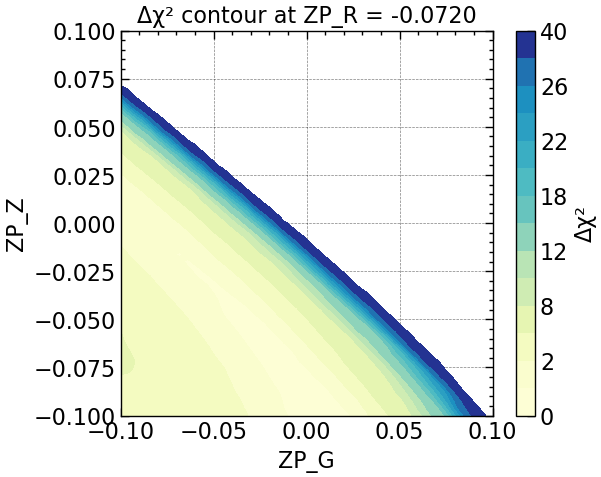

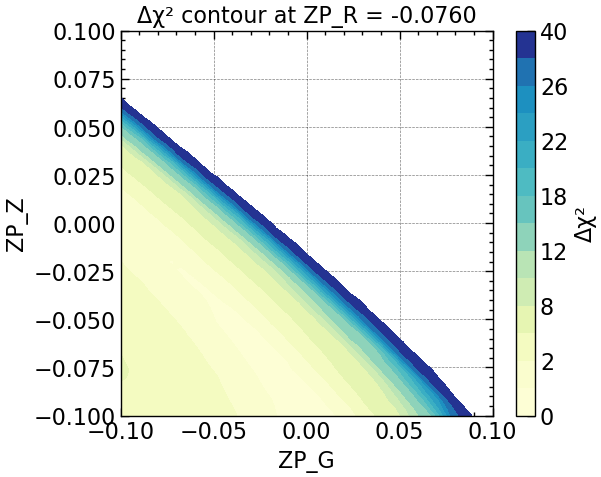

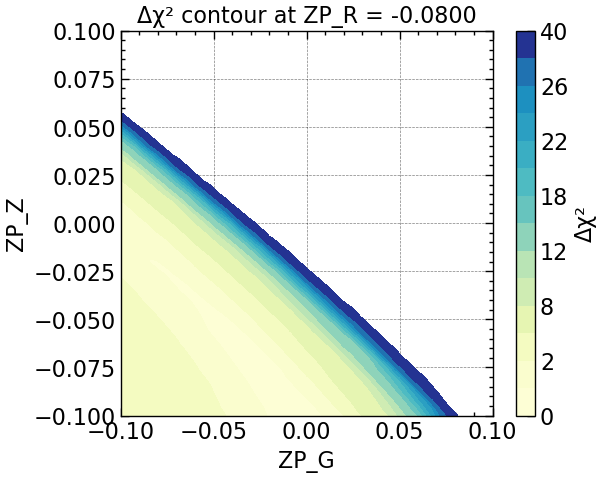

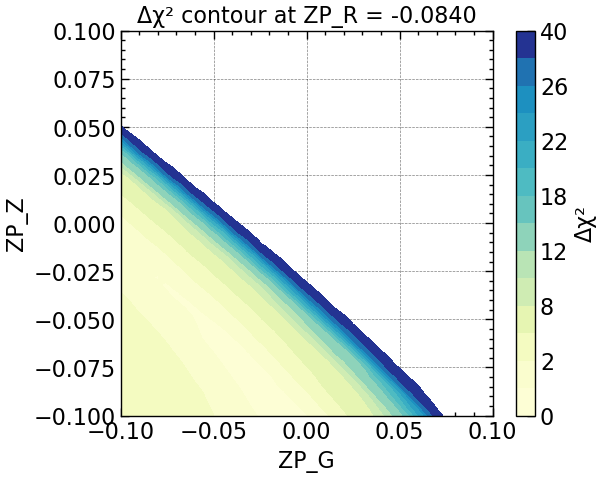

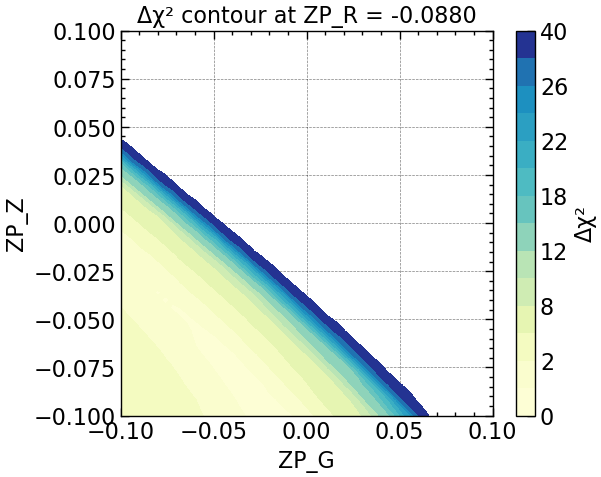

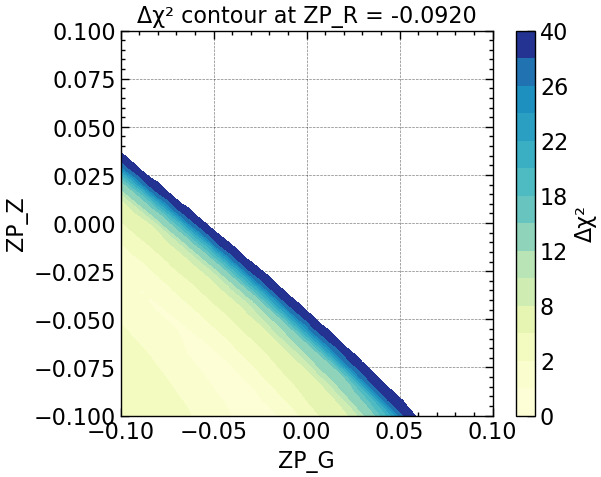

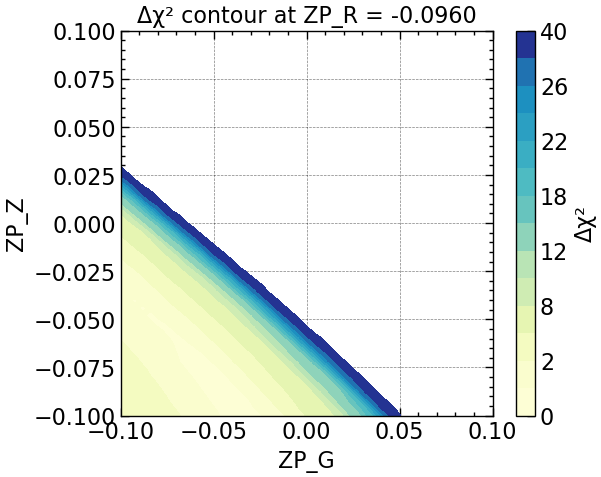

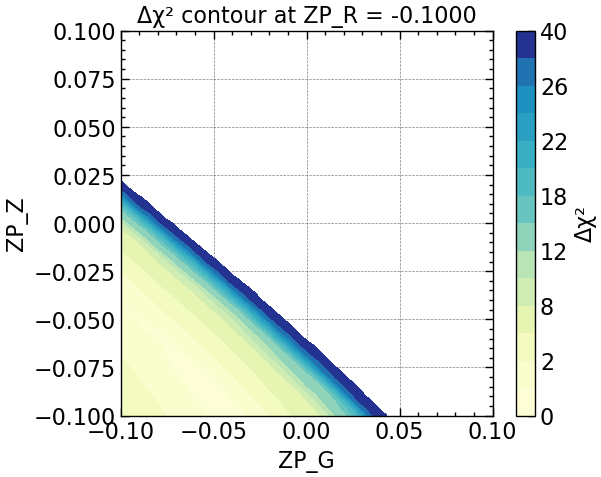

In [43]:
import matplotlib.pyplot as plt
import numpy as np

chi = chi_square_grid - np.nanmin(chi_square_grid)
grid = grid_values

for k in range(len(grid)):
    slice_2d = chi[:, k, :]
    slice_2d = np.where(np.isinf(slice_2d), np.nan, slice_2d)
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    plt.figure(figsize=(6,5))
    cs = plt.contourf(X, Y, slice_2d, levels=[0,1,2,4,8,10,12,16,18,20,22,24,26,30,40], cmap='YlGnBu')
    plt.colorbar(cs, label='Δχ²')
    plt.title(f"Δχ² contour at ZP_R = {grid[k]:.4f}")
    plt.xlabel("ZP_G")
    plt.ylabel("ZP_Z")

In [54]:
ix = np.array(np.where(chi<0.1)).T

In [92]:
from itertools import product
points = list(product(grid_values, repeat=3)) 

In [80]:
ix

condition = (np.where(chi<0.05))
np.array([grid_values[condition[0]], grid_values[condition[1]], grid_values[condition[2]]]).T

array([[ 0.1  ,  0.016, -0.084],
       [ 0.1  ,  0.012, -0.088],
       [ 0.1  ,  0.012, -0.092],
       [ 0.1  ,  0.008, -0.096],
       [ 0.1  ,  0.004, -0.1  ],
       [ 0.096,  0.008, -0.092],
       [ 0.096,  0.008, -0.096],
       [ 0.096,  0.004, -0.1  ],
       [ 0.092,  0.004, -0.096],
       [ 0.092,  0.004, -0.1  ],
       [ 0.088,  0.   , -0.1  ]])

In [88]:
condition = np.where(chi < 0.1)
selected_zp_G = grid_values[condition[0]]
selected_zp_R = grid_values[condition[1]]
selected_zp_Z = grid_values[condition[2]]
selected_chi = chi[condition]

# Sort by chi-square values
sort_indices = np.argsort(selected_chi)
selected_zp_G = selected_zp_G[sort_indices]
selected_zp_R = selected_zp_R[sort_indices]
selected_zp_Z = selected_zp_Z[sort_indices]
selected_chi = selected_chi[sort_indices]

print(f"Number of grid points with Δχ² < 0.1: {len(selected_chi)}\n")
print("ZP_G\t\tZP_R\t\tZP_Z\t\tΔχ²")
print("-" * 60)
for i in range(len(selected_chi)):
    print(f"{selected_zp_G[i]:.6f}\t{selected_zp_R[i]:.6f}\t{selected_zp_Z[i]:.6f}\t{selected_chi[i]:.6f}")

Number of grid points with Δχ² < 0.1: 33

ZP_G		ZP_R		ZP_Z		Δχ²
------------------------------------------------------------
0.100000	0.004000	-0.100000	0.000000
0.100000	0.012000	-0.092000	0.006309
0.096000	0.008000	-0.096000	0.010261
0.092000	0.004000	-0.100000	0.011137
0.100000	0.008000	-0.096000	0.023199
0.096000	0.004000	-0.100000	0.023987
0.088000	0.000000	-0.100000	0.040875
0.100000	0.012000	-0.088000	0.043699
0.100000	0.016000	-0.084000	0.044481
0.096000	0.008000	-0.092000	0.047374
0.092000	0.004000	-0.096000	0.047926
0.100000	0.016000	-0.088000	0.053844
0.084000	0.000000	-0.100000	0.055118
0.096000	0.012000	-0.088000	0.055218
0.096000	0.016000	-0.084000	0.056852
0.092000	0.008000	-0.092000	0.058542
0.088000	0.004000	-0.096000	0.060579
0.096000	0.000000	-0.100000	0.062489
0.100000	0.020000	-0.080000	0.066100
0.096000	0.012000	-0.092000	0.066394
0.080000	0.000000	-0.100000	0.070056
0.100000	0.004000	-0.096000	0.070574
0.092000	0.012000	-0.088000	0.071054
0.092000	0.008000	-0.096

In [101]:
np.linspace(0.15, -0.15, 61)

array([ 0.15 ,  0.145,  0.14 ,  0.135,  0.13 ,  0.125,  0.12 ,  0.115,
        0.11 ,  0.105,  0.1  ,  0.095,  0.09 ,  0.085,  0.08 ,  0.075,
        0.07 ,  0.065,  0.06 ,  0.055,  0.05 ,  0.045,  0.04 ,  0.035,
        0.03 ,  0.025,  0.02 ,  0.015,  0.01 ,  0.005,  0.   , -0.005,
       -0.01 , -0.015, -0.02 , -0.025, -0.03 , -0.035, -0.04 , -0.045,
       -0.05 , -0.055, -0.06 , -0.065, -0.07 , -0.075, -0.08 , -0.085,
       -0.09 , -0.095, -0.1  , -0.105, -0.11 , -0.115, -0.12 , -0.125,
       -0.13 , -0.135, -0.14 , -0.145, -0.15 ])

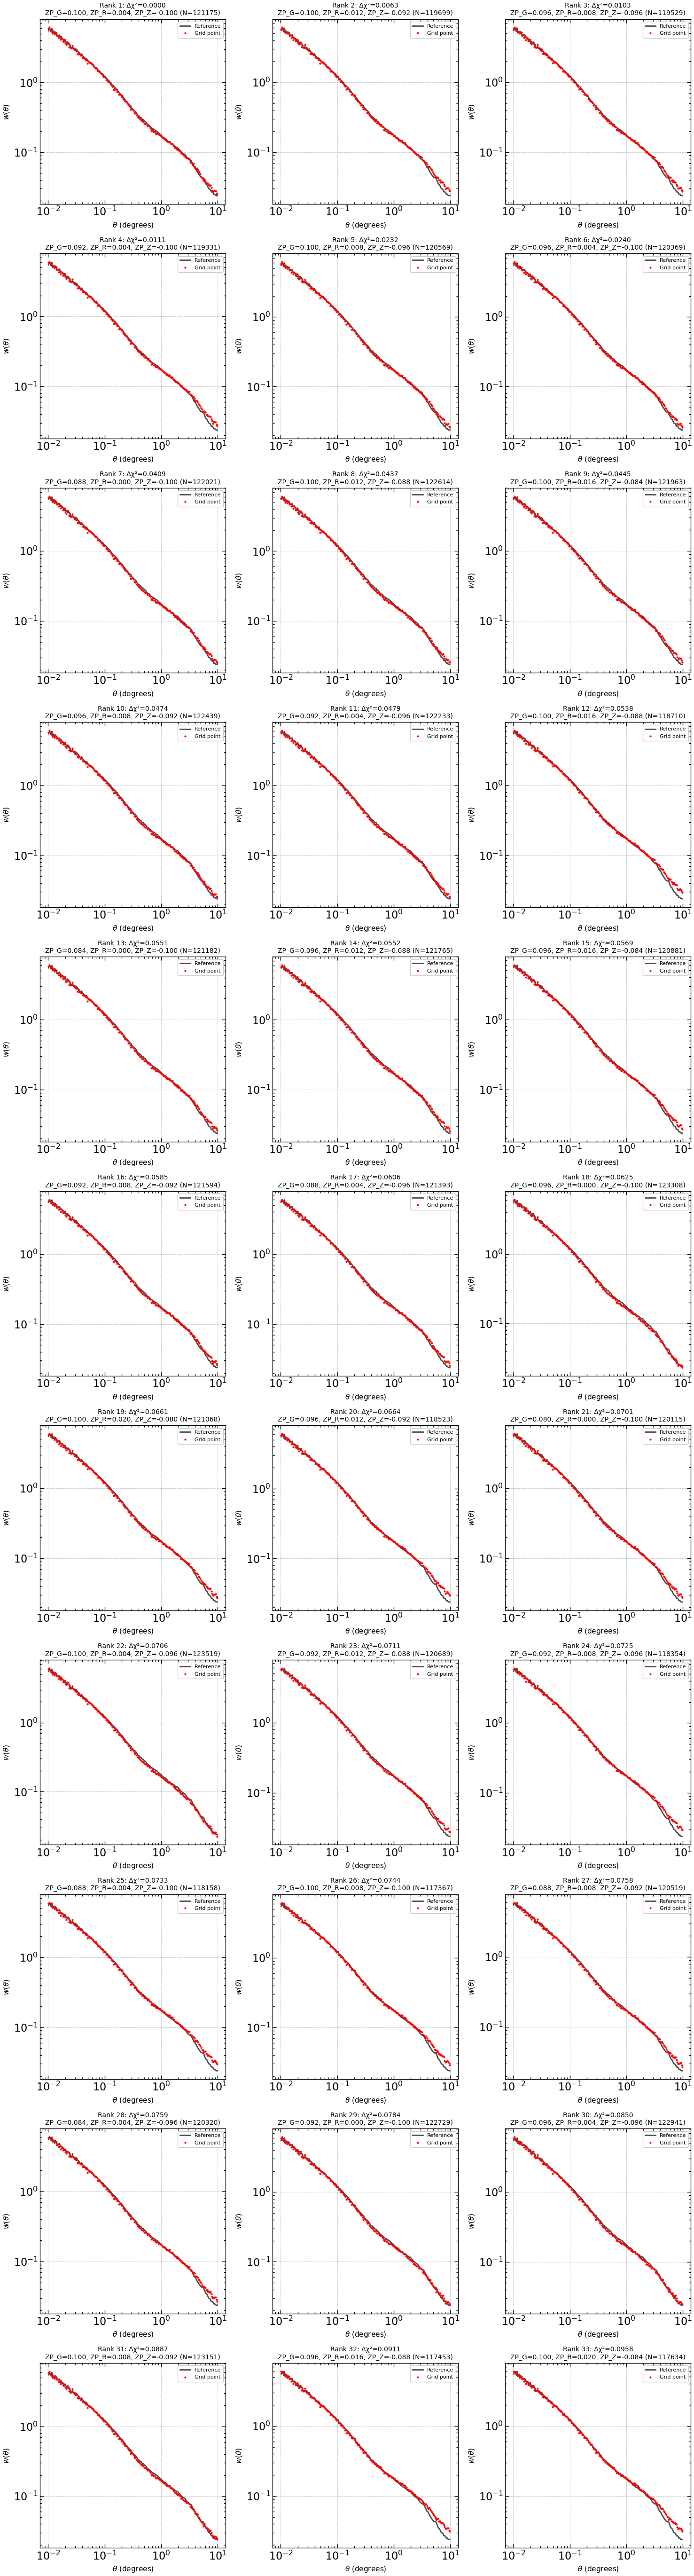

Number of grid points with Δχ² < 0.05: 33
Δχ² range: [0.000000, 0.095772]


In [97]:
condition = np.where(chi < 0.1)
selected_indices = np.array([condition[0], condition[1], condition[2]]).T

# Get chi-square values for selected indices
selected_chi_values = chi[condition]

# Sort indices by chi-square values
sorted_order = np.argsort(selected_chi_values)
sorted_indices = selected_indices[sorted_order]
sorted_chi = selected_chi_values[sorted_order]

# Plot each w_theta in separate subplots
n_plots = len(sorted_indices)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx_num, (idx, ax) in enumerate(zip(sorted_indices, axes)):
    i, j, k = idx
    if valid_mask[i, j, k]:
        n_bins = n_bins_array[i, j, k]
        theta_bins = theta_bins_array[i, j, k, :n_bins]
        w_theta = w_theta_array[i, j, k, :n_bins]
        
        # Plot reference
        ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=2, 
                  label='Reference', alpha=0.7)
        # Plot grid point
        ax.loglog(theta_bins, w_theta, 'r.', markersize=4, 
                 label=f'Grid point')
        
        ax.set_xlabel(r'$\theta$ (degrees)', fontsize=11)
        ax.set_ylabel(r'$w(\theta)$', fontsize=11)
        ax.set_title(f'Rank {idx_num+1}: Δχ²={sorted_chi[idx_num]:.4f}\n' +
                    f'ZP_G={grid_values[i]:.3f}, ZP_R={grid_values[j]:.3f}, ZP_Z={grid_values[k]:.3f}' +
                    f' (N={n_objects[i, j, k]})',
                    fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Number of grid points with Δχ² < 0.05: {len(sorted_indices)}")
print(f"Δχ² range: [{sorted_chi.min():.6f}, {sorted_chi.max():.6f}]")


/tmp/ipykernel_114522/2722676376.py:36: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(sm, ax=ax, label='Δχ²')


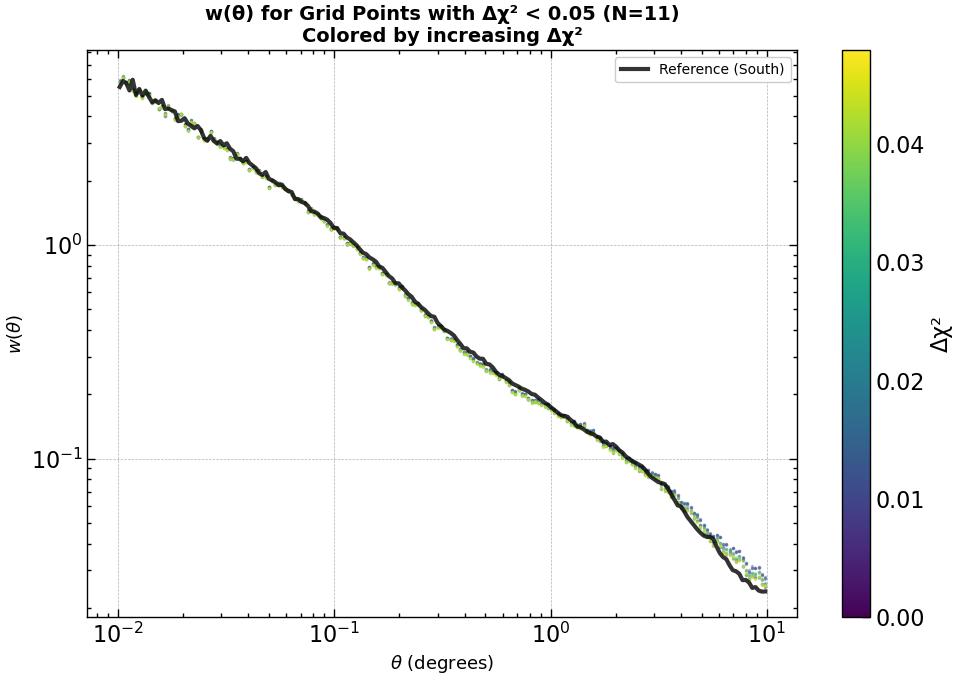

Number of grid points with Δχ² < 0.05: 11
Δχ² range: [0.000000, 0.047926]


In [ ]:
condition = np.where(chi < 0.05)
selected_indices = np.array([condition[0], condition[1], condition[2]]).T

# Get chi-square values for selected indices
selected_chi_values = chi[condition]

# Sort indices by chi-square values
sorted_order = np.argsort(selected_chi_values)
sorted_indices = selected_indices[sorted_order]
sorted_chi = selected_chi_values[sorted_order]

#

# Plot reference w_theta
ax.loglog(reference_theta_bins, reference_w_theta, 'k-', linewidth=3, 
          label='Reference (South)', alpha=0.8, zorder=100)

# Plot all w_theta with chi < 0.05 in increasing chi-square order
# Use colormap to show progression from best to worst fit
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, len(sorted_indices)))

for idx_num, idx in enumerate(sorted_indices):
    i, j, k = idx
    if valid_mask[i, j, k]:
        n_bins = n_bins_array[i, j, k]
        theta_bins = theta_bins_array[i, j, k, :n_bins]
        w_theta = w_theta_array[i, j, k, :n_bins]
        
        ax.loglog(theta_bins, w_theta, '.', alpha=0.3, color=colors[idx_num],
                 markersize=3)

# Add colorbar to show chi-square progression
sm = cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=sorted_chi.min(), vmax=sorted_chi.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Δχ²')

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=13)
ax.set_ylabel(r'$w(\theta)$', fontsize=13)
ax.set_title(f'w(θ) for Grid Points with Δχ² < 0.05 (N={len(sorted_indices)})\nColored by increasing Δχ²', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print(f"Number of grid points with Δχ² < 0.05: {len(sorted_indices)}")
print(f"Δχ² range: [{sorted_chi.min():.6f}, {sorted_chi.max():.6f}]")
